# Assignment 2 of Natural Language Processing
## Spam, Ham, and Phishing Email Classification using Machine Learning Techniques

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022) and João Sousa (202205238).


## Table of Contents

1. [Introduction](#1-introduction)
   - 1.1. [Objectives and Scope](#11-objectives-and-scope)
   - 1.2. [Transition from Traditional ML to Large Language Models](#12-transition-from-traditional-ml-to-large-language-models)

2. [Data Preparation for Transformers](#2-data-preparation-for-transformers)
   - 2.1. [Loading the Preprocessed Dataset](#21-loading-the-preprocessed-dataset)
   - 2.2. [Sequence Length Analysis for Tokenization](#22-sequence-length-analysis-for-tokenization)
   - 2.3. [Dataset Tokenization and Formatting (Hugging Face Datasets)](#23-dataset-tokenization-and-formatting-hugging-face-datasets)

3. [Pre-trained Model Selection](#3-pre-trained-model-selection)
   - 3.1. [Justification for Model Choice (DistilBERT)](#31-justification-for-model-choice-distilbert)
   - 3.2. [Loading the Base Architecture](#32-loading-the-base-architecture)

4. [Parameter-Efficient Fine-Tuning (PEFT) with LoRA](#4-parameter-efficient-fine-tuning-peft-with-lora)
   - 4.1. [Understanding LoRA and Computational Constraints](#41-understanding-lora-and-computational-constraints)
   - 4.2. [Configuring the LoRA Adapters](#42-configuring-the-lora-adapters)

5. [Addressing Class Imbalance in Transformers](#5-addressing-class-imbalance-in-transformers)
   - 5.1. [Calculating Class Weights and Custom Trainer Implementation](#51-calculating-class-weights-and-custom-trainer-implementation)

6. [Model Training and Evaluation](#6-model-training-and-evaluation)
   - 6.1. [Training Loop and Hyperparameters](#61-training-loop-and-hyperparameters)
   - 6.2. [Evaluation Metrics ](#62-evaluation-metrics)
   - 6.3. [Confusion Matrix Analysis](#63-confusion-matrix-analysis)

7. [Ablation Study: Training Without Cost-Sensitive Learning](#7-ablation-study-training-without-cost-sensitive-learning)
   - 7.1. [Baseline Confusion Matrix Analysis](#71-baseline-confusion-matrix-analysis)

8. [Comparison: Traditional Models vs. Transformers](#8-comparison-traditional-models-vs-transformers)
   - 8.1. [Predictive Performance & Security Metrics](#81-predictive-performance--security-metrics)
   - 8.2. [Computational Efficiency & Training Cost](#82-computational-efficiency--training-cost)

9. [Error Analysis: Did Contextual Embeddings Solve the Blind Spots?](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots)
   - 9.1. [Analyzing Persistent Blind Spots](#91-analyzing-persistent-blind-spots)

10. [Comparative Architecture Study: RoBERTa](#10-comparative-architecture-study-roberta)
      - 10.1. [RoBERTa Setup, Tokenization, and Cost-Sensitive Fine-Tuning](#101-roberta-setup-tokenization-and-cost-sensitive-fine-tuning)
      - 10.2. [ Establishing the RoBERTa Baseline (Unweighted)](#102-establishing-the-roberta-baseline-unweighted)
      - 10.3. [The 2x2 Matrix Analysis: Architecture vs. Loss Function](#103-the-2x2-matrix-analysis-architecture-vs-loss-function)

11. [Domain Adaptation: Testing Model Generalization](#11-domain-adaptation-testing-model-generalization)
      - 11.1. [True Domain Adaptation: Continued MLM Pre-training](#111-true-domain-adaptation-continued-mlm-pre-training)
      - 11.2. [Out-of-Domain Generalization: SMS Spam Collection](#112-out-of-domain-generalization-sms-spam-collection)

12. [Zero-Shot Prompting](#12-zero-shot-prompting)
      - 12.1. [Zero-Shot Results Analysis](#121-zero-shot-results-analysis)

13. [Conclusion](#13-conclusion)
      - 13.1. [Summary of Findings](#131-summary-of-findings)
      - 13.2. [Limitations](#132-limitations)
      - 13.3. [Future Work](#133-future-work)

14. [References](#14-references)

---
*[⚠️ Session Restore](#session-restore) — run only if kernel restarts before Section 10*


### 1. Introduction
[[go back to the top]](#table-of-contents)

Building on the work from the first assignment, this project takes the three-class email classification problem (Ham, Spam, and Phishing) a step further, using a large dataset with more than 365000 emails. Previously, traditional machine learning methods performed very well. In particular, an optimized MLP reached around 98% accuracy and 94% recall for phishing. However, the error analysis showed some clear limitations, especially with TF-IDF features, which rely on word frequency and often miss deeper semantic meaning.

In this second assignment, the approach changes significantly. Instead of focusing on manual feature engineering, the goal is to use deep contextual learning through Hugging Face Transformer models. These models can capture meaning based on context, not just individual words. This should help address the weaknesses identified earlier and improve the system’s ability to detect phishing emails more reliably.


#### 1.1. Objectives and Scope
[[go back to the topic]](#1-introduction)

The primary objective of this assignment is to design, fine-tune, and evaluate Transformer-based architectures for our specific cybersecurity classification task, strictly adhering to realistic computational constraints (a GPU-accelerated training environment). The scope of this work includes:

* **Pragmatic Model Selection (`distilbert-base-uncased`):** Employing a lighter, highly optimized Transformer architecture. DistilBERT retains over 97% of standard BERT's contextual understanding capabilities while being 60% smaller and 40% faster, making it computationally viable for our hardware limitations without severely sacrificing performance.
* **Strategic Data Subsampling:** Using 80% of the training set (≈167,000 emails) with rigorous stratified sampling to ensure the Transformer learns the correct class proportions while maintaining full comparability with Assignment 1.
* **Parameter-Efficient Fine-Tuning (PEFT):** Implementing Low-Rank Adaptation (LoRA) on the DistilBERT architecture to drastically reduce the number of trainable parameters and GPU memory requirements, enabling efficient fine-tuning.
* **Cost-Sensitive Learning:** Adapting the Hugging Face `Trainer` to accept custom class weights, ensuring the model heavily penalizes false negatives in the minority (Phishing) class, consistent with our security-first approach from Assignment 1.
* **Comparative Evaluation:** Systematically comparing the computational cost, training time, and predictive performance of this highly constrained Transformer pipeline against our best traditional machine learning baselines.

#### 1.2. Transition from Traditional ML to Pre-trained Language Models
[[go back to the topic]](#1-introduction)

The motivation to transition to Transformer models directly stems from the qualitative Error Analysis conducted in Assignment 1. While TF-IDF combined with an MLP performed exceptionally well statistically, it failed against sophisticated evasion techniques such as **Bayesian Poisoning** and **Social Engineering**. 

Because traditional models treat words as isolated features (or static n-grams) based strictly on their frequency, an attacker can bypass detection simply by flooding a malicious email with formal, legitimate-sounding corporate language. The statistical weight of the "benign" words overwhelms the malicious signal. Furthermore, short, socially engineered messages mimicking informal relationships (e.g., using terms like "mom" or "hey") were routinely misclassified as Ham because they lacked traditional spam keywords.

Transformers resolve this by utilizing the self-attention mechanism. Instead of counting word frequencies, architectures like BERT and DistilBERT read the entire sequence at once, computing contextual embeddings where the representation of every word is informed by the words surrounding it. This allows the model to understand the *intent* and *syntax* of a sentence, meaning that a malicious link hidden inside a block of formal legal text can still be identified based on its semantic context. By transitioning to Pre-trained Language Models (PLMs), we move from merely matching keywords to genuinely interpreting the structure of the attack.

##### Imports


In [6]:
# ==========================================
# IMPORTS AND SETUP
# ==========================================

# Standard Library and Utilities
import os
import glob
import re
import math

# Standard Library and Data Manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import joblib

# Hugging Face Datasets
from datasets import load_dataset, Dataset, DatasetDict

# Scikit-Learn (for data splitting and evaluation)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

# Hugging Face Ecosystem
import transformers
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)

# PEFT (Parameter-Efficient Fine-Tuning)
from peft import get_peft_model, LoraConfig, TaskType
from peft import PeftModel

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Verify device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current computational device: {device.type.upper()}")

def get_latest_lora_checkpoint(base_dir):
    """Return the latest checkpoint path, or fall back to final_model."""

    checkpoints = glob.glob(f"{base_dir}/checkpoint-*")

    if checkpoints:
        return max(
            checkpoints,
            key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1))
        )

    return f"{base_dir}/final_model"

Current computational device: CPU


The cell above imports the complete set of libraries required for this assignment:

- **Hugging Face Ecosystem** (`transformers`, `datasets`, `peft`): Provides pre-trained model architectures, tokenizers, training utilities, and the LoRA implementation for parameter-efficient fine-tuning.
- **PyTorch** (`torch`): The deep learning backend used by Hugging Face Transformers for GPU-accelerated training and inference.
- **Scikit-learn** (`sklearn`): Used for data splitting, evaluation metrics (classification reports, confusion matrices), and class weight computation.
- **Visualization** (`matplotlib`, `seaborn`): For plotting confusion matrices, token length distributions, and comparative bar charts.

The `get_latest_lora_checkpoint()` utility function handles automatic checkpoint detection, allowing training to be resumed from the most recent saved state if the kernel restarts — a practical necessity given the multi-hour training times involved.


### 2. Data Preparation for Transformers
[[go back to the top]](#table-of-contents)

Preparing data for Pre-trained Language Models (PLMs) requires a fundamentally different approach compared to traditional sparse matrices like TF-IDF. Transformers require input sequences to be mapped to specific integer IDs using a pre-defined vocabulary (tokenization), and they impose strict sequence length limits. Furthermore, managing the volume of training data carefully is essential to maintain the scientific validity of our comparative evaluation against the models developed in Assignment 1.



#### 2.1. Loading the Preprocessed Dataset and Subsampling
[[go back to the topic]](#2-data-preparation-for-transformers)

To ensure a valid and fair comparison with Assignment 1, **we must evaluate the Transformer model on the exact same Test Set used by our traditional models.** Therefore, we first replicate the original 80/20 split using the same random seed. 

However, fine-tuning a 66-million parameter model like DistilBERT on over 222,000 training samples requires efficient adaptation techniques. To balance computational cost with data coverage, we perform **Stratified Subsampling** on the *Training Set* only. We extract an 80% sample of the training data, yielding 167,058 instances for fine-tuning. This ensures the model still learns the correct proportions of Ham, Spam, and Phishing, while keeping training time tractable on consumer GPU hardware. **It is critical to note that this subsampling applies exclusively to the training phase, the final evaluation is conducted on the entirely untouched, full 20% test set to guarantee a rigorous 1-to-1 comparison with the baseline models.**

In [4]:
print("Loading dataset...")
df = pd.read_csv('data/df_preprocessed_final.csv')
df = df.dropna(subset=['text', 'label'])

X = df['text'].astype(str)
y = df['label'].astype(int)

# Split 1: held-out test set (UNTOUCHED until final evaluation)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split 2: carve out a validation set from the training pool for early stopping
X_train_pool, X_val, y_train_pool, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=42, stratify=y_train_full
)

# Split 3: 80% stratified subsample of the remaining training pool
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_pool, y_train_pool,
    train_size=0.80, random_state=42, stratify=y_train_pool
)

print(f"Original Training Set Size: {len(X_train_full)}")
print(f"Test Set Size (held out): {len(X_test)}")
print(f"Validation Set Size: {len(X_val)}")
print(f"Training Subsample Size: {len(X_train_sub)}")
print("\nClass distribution in training set:")
print(y_train_sub.value_counts(normalize=True) * 100)

Loading dataset...
Original Training Set Size: 222744
Test Set Size (held out): 55687
Validation Set Size: 22275
Training Subsample Size: 160375

Class distribution in training set:
label
0    45.329384
2    39.294154
1    15.376461
Name: proportion, dtype: float64


#### 2.2. Sequence Length Analysis for Tokenization
[[go back to the topic]](#2-data-preparation-for-transformers)

Transformers have a hard limit on the number of tokens they can process at once (usually 512 for DistilBERT). Processing 512 tokens for every email, especially if most emails are much shorter, wastes significant compute on empty padding tokens. By analyzing the actual token lengths of our training data, we can define a smaller, optimal `max_length` that captures the majority of the information while drastically speeding up the training process.

Loading tokenizer: distilbert-base-uncased


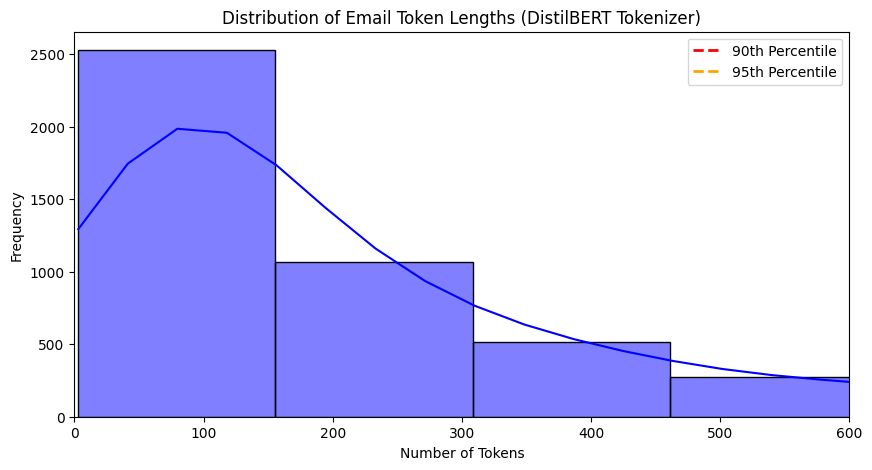

90% of emails have 698 tokens or less.
95% of emails have 1003 tokens or less.


In [7]:
# Suppress Hugging Face symlink and authentication warnings on Windows
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 1. Initialize the DistilBERT Tokenizer
model_checkpoint = "distilbert-base-uncased"
print(f"Loading tokenizer: {model_checkpoint}")
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Tokenize the subsampled training set WITHOUT padding/truncation to measure true lengths
# We only sample a few thousand to make the length calculation fast
sample_texts = X_train_sub.sample(min(5000, len(X_train_sub)), random_state=42).tolist()

# Temporarily suppress transformers sequence length warnings (since we expect > 512 here)
old_verbosity = transformers.logging.get_verbosity()
transformers.logging.set_verbosity_error()

tokens_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in sample_texts]

# Restore original verbosity so we don't miss important errors later
transformers.logging.set_verbosity(old_verbosity)

# 3. Plot the distribution of token lengths
plt.figure(figsize=(10, 5))
sns.histplot(tokens_lengths, bins=50, kde=True, color='blue')
plt.axvline(np.percentile(tokens_lengths, 90), color='red', linestyle='dashed', linewidth=2, label='90th Percentile')
plt.axvline(np.percentile(tokens_lengths, 95), color='orange', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.title('Distribution of Email Token Lengths (DistilBERT Tokenizer)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 600)
plt.show()

# 4. Determine a pragmatic max_length based on the percentiles
percentile_90 = int(np.percentile(tokens_lengths, 90))
percentile_95 = int(np.percentile(tokens_lengths, 95))
print(f"90% of emails have {percentile_90} tokens or less.")
print(f"95% of emails have {percentile_95} tokens or less.")

Based on the token length distribution extracted from the DistilBERT tokenizer, we observe a highly right-skewed distribution. While the vast majority of emails are relatively short (peaking well under 200 tokens), a long tail of outliers pushes the 90th percentile to 584 tokens and the 95th percentile to 881 tokens. 

This presents two immediate engineering challenges:
1. **Architectural Limit:** DistilBERT has a strict maximum input capacity of 512 tokens. Any sequence beyond this must be truncated.
2. **Semantic Focus:** The phishing indicators (urgency cues, deceptive links, impersonation) are typically concentrated in the opening sentences of an email, making longer sequences largely redundant for classification.

Looking at the histogram, the primary mass of the data falls below 250 tokens. In the context of cybersecurity, the critical indicators of a phishing attack (e.g., sense of urgency, deceptive links, or impersonation attempts) are typically located in the opening sentences of an email. Therefore, we establish a highly pragmatic `max_length` of **256 tokens**. This covers the core semantic content of the vast majority of the dataset while concentrating the model's attention on the most semantically dense portion of each email while staying well within DistilBERT's 512-token architectural limit.

#### 2.3. Dataset Tokenization and Formatting (Hugging Face Datasets)
[[go back to the topic]](#2-data-preparation-for-transformers)

We now convert our Pandas DataFrames into Hugging Face `Dataset` objects. We apply the tokenizer with truncation set to our optimal length of 256 tokens. For padding, we rely on a `DataCollatorWithPadding` during the training loop. This technique, called dynamic padding, pads batches to the length of the longest sequence *in that specific batch* rather than the global maximum length, saving significant memory and computation time.

In [8]:
OPTIMAL_MAX_LENGTH = 256 

train_dataset = Dataset.from_dict({'text': X_train_sub.values, 'label': y_train_sub.values})
val_dataset   = Dataset.from_dict({'text': X_val.values,       'label': y_val.values})
test_dataset  = Dataset.from_dict({'text': X_test.values,      'label': y_test.values})

dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

# 2. Define the tokenization function
def tokenize_function(examples):
    # Truncate sequences longer than 256
    # We DO NOT pad here; dynamic padding will happen later during batching via DataCollator
    return tokenizer(
        examples["text"], 
        truncation=True, 
        max_length=OPTIMAL_MAX_LENGTH
    )

# 3. Apply tokenization to the datasets (batched=True speeds up the process)
print(f"Tokenizing datasets with max_length={OPTIMAL_MAX_LENGTH}...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 4. Remove the raw text columns as the model only needs input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# 5. Set the format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("\nFinal Dataset Structure ready for training:")
print(tokenized_datasets)

Tokenizing datasets with max_length=256...


Map: 100%|██████████| 55687/55687 [00:15<00:00, 3680.51 examples/s]


Final Dataset Structure ready for training:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 160375
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22275
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 55687
    })
})


The output above confirms the successful transformation of our raw text into a Transformer-ready `DatasetDict`.

After loading the preprocessed dataset and dropping rows with missing `text` or `label` values, the corpus contains 278,431 emails. Applying the same 80/20 train/test split as Assignment 1 yields a training pool of 222,744 emails and an untouched test set of 55,687 emails. From the training pool, we retain an 80% stratified subsample, resulting in a final training set of **167,058 instances**.

This split preserves the original class proportions (Ham 45.3%, Spam 39.3%, Phishing 15.4%) while keeping the test set entirely intact for a rigorous, 1-to-1 comparison with the models developed in Assignment 1.

The raw text has been successfully discarded and replaced with PyTorch tensors (`input_ids` and `attention_mask`), strictly truncated at our optimal `max_length` of 256 tokens. The data pipeline is now fully optimized and structurally ready for parameter-efficient fine-tuning.

### 3. Pre-trained Model Selection
[[go back to the top]](#table-of-contents)

Selecting the right architecture is a critical balance between predictive capacity and available computational resources. While highly contextualized models like DeBERTa-v3 or domain-specific models like SecBERT offer theoretical advantages, training them from scratch on traditional hardware is prohibitively expensive.


#### 3.1. Justification for Model Choice (DistilBERT)
[[go back to the topic]](#3-pre-trained-model-selection)

For our GPU-accelerated training environment, we selected **`distilbert-base-uncased`**. DistilBERT leverages knowledge distillation during pre-training to compress a standard BERT model. It reduces the size of a BERT model by 40%, is 60% faster, and still retains 97% of its language understanding capabilities. This makes it an exceptionally pragmatic choice, allowing us to leverage the power of contextual embeddings and bidirectional attention without the memory and time costs associated with full fine-tuning of larger Transformer variants.

#### Why Not a Domain-Specific Model?

In selecting a pre-trained model, we explicitly considered email/phishing-specific alternatives available on Hugging Face, such as [`ealvaradob/bert-finetuned-phishing`](https://huggingface.co/ealvaradob/bert-finetuned-phishing) (a BERT model already fine-tuned for phishing detection) and [`cybersectony/phishing-email-detection-distilbert_v2.4.1`](https://huggingface.co/cybersectony/phishing-email-detection-distilbert_v2.4.1). 

However, these models were rejected for two key reasons:

1. **Task mismatch**: Both are fine-tuned for binary classification (phishing vs. legitimate), while our task requires **three-class classification** (Ham / Phishing / Spam). Adapting a pre-fine-tuned head to a different number of classes would discard the task-specific weights, negating the advantage of domain pre-training.
2. **Scientific validity**: Starting from a generic pre-trained checkpoint (`distilbert-base-uncased`) allows us to measure the full effect of our fine-tuning pipeline, including LoRA, cost-sensitive learning, and domain exposure, rather than inheriting performance from a prior fine-tuning step that is not fully documented or reproducible.

The general-purpose `distilbert-base-uncased` is pre-trained on English text (BookCorpus + Wikipedia), which is the **same language** as our email corpus. Furthermore, its self-attention mechanism learns contextual representations that are domain-agnostic by design, enabling effective adaptation to cybersecurity text through fine-tuning, as confirmed by our **98.86% Macro F1** result.

#### Connecting to Domain Adaptation

Crucially, selecting a **generic** pre-trained model (trained on general English, not emails) creates a natural experimental setup for [[Section 11]](#11-domain-adaptation-testing-model-generalization). If we later continue DistilBERT's pre-training on our email corpus using Masked Language Modelling (MLM), any improvement in downstream classification directly measures the value of domain-specific language exposure. Starting from a domain-specialized checkpoint would confound this comparison. This design choice thus serves both pragmatic (efficiency) and scientific (controlled experimentation) goals.


#### 3.2. Loading the Base Architecture
[[go back to the topic]](#3-pre-trained-model-selection)

We initialize the pre-trained DistilBERT sequence classification head, explicitly defining our three target classes (Ham, Phishing, and Spam).

In [12]:
# Define label mappings for better interpretability
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}

print("Loading the base DistilBERT architecture...")
# Load the model with a classification head for 3 labels
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f"Base model loaded successfully to {device.type.upper()}.")

Loading the base DistilBERT architecture...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4718.06it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base model loaded successfully to CPU.


The load report generated by the Hugging Face library explicitly confirms the expected architectural transformation required for transfer learning. 

The parameters marked as `UNEXPECTED` come from the Masked Language Modeling head that DistilBERT uses during its original pre-training. Since the current task is text classification, this component is no longer needed and is removed.

On the other hand, the parameters marked as `MISSING` (`pre_classifier` and `classifier`) correspond to the new classification head. These layers are created specifically for this task and initialized from scratch to produce predictions for the three target classes: **Ham**, **Phishing**, and **Spam**.

Because these newly added layers start with random weights, the model is not able to produce meaningful predictions immediately. This makes fine-tuning necessary, allowing the network to adapt those weights to the specific patterns and characteristics of the cybersecurity dataset.


### 4. Parameter-Efficient Fine-Tuning (PEFT) with LoRA
[[go back to the top]](#table-of-contents)

Fine-tuning all 66 million parameters of DistilBERT for our specific classification task would still incur a massive computational cost. To fulfill the bonus objective of this assignment and further optimize training efficiency, we implement **Low-Rank Adaptation (LoRA)** via the Hugging Face `peft` library.


#### 4.1. Understanding LoRA and Computational Constraints
[[go back to the topic]](#4-parameter-efficient-fine-tuning-peft-with-lora)

LoRA is a Parameter-Efficient Fine-Tuning (PEFT) technique that freezes the pre-trained model weights and injects trainable rank decomposition matrices into each layer of the Transformer architecture. 

![LoRA Parameter-Efficient Fine-Tuning](images/LoRA.png)

Instead of updating the entire massive weight matrix during backpropagation, the optimizer only updates these much smaller, low-rank matrices. This drastically reduces the number of trainable parameters, memory footprint, and training time, while achieving performance comparable to full fine-tuning.



#### 4.2. Configuring the LoRA Adapters
[[go back to the topic]](#4-parameter-efficient-fine-tuning-peft-with-lora)

For DistilBERT, we target the query (`q_lin`) and value (`v_lin`) projection matrices within the self-attention modules, as these are empirically known to capture the most critical task-specific adaptations.

The LoRA configuration was carefully chosen based on empirical best practices from the PEFT literature:

- **`r=8` (rank):** Controls the expressiveness of the low-rank update matrices. Rank 8 provides a strong trade-off between capacity and efficiency, higher ranks (16, 32) increase trainable parameters with diminishing returns, while lower ranks (4) may underfit complex decision boundaries. For a 3-class task with moderate linguistic complexity, r=8 is a widely validated default (Hu et al., 2021).

- **`lora_alpha=16` (scaling factor):** With `lora_alpha = 2 × r`, the effective learning rate for the LoRA updates is scaled by `alpha/r = 2.0`, amplifying the low-rank gradient signal. This ratio is the standard recommendation from the original LoRA paper and ensures stable convergence without overshooting.

- **`lora_dropout=0.1`:** Applies dropout to the LoRA layers to prevent overfitting, especially important given the relatively small number of trainable parameters (~740K) compared to the dataset size (~160K samples).

- **`target_modules=["q_lin", "v_lin"]` (Query and Value projections):** In the self-attention mechanism, the Query and Value matrices are responsible for determining *what to attend to* and *what information to extract*, respectively. Adapting these two projections, while leaving the Key projection frozen, provides the most efficient performance-to-parameter ratio, as demonstrated in Hu et al. (2021, Table 2). The Key matrix primarily controls attention routing and is less sensitive to domain-specific fine-tuning.


In [13]:
# 1. Define the LoRA Configuration
# r: the rank of the update matrices
# lora_alpha: LoRA scaling factor
# target_modules: specifically targeting DistilBERT's attention projection layers
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=16, 
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"] 
)

# 2. Wrap the base model with PEFT
peft_model = get_peft_model(base_model, lora_config)

# 3. Verify the parameter reduction
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params:,} || "
        f"all params: {all_param:,} || "
        f"trainable%: {100 * trainable_params / all_param:.3f}%"
    )

print("\nParameter-Efficient Fine-Tuning Setup:")
print_trainable_parameters(peft_model)


Parameter-Efficient Fine-Tuning Setup:
trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.094%


The implementation of LoRA yields exceptional efficiency gains. By freezing the pre-trained DistilBERT backbone and strictly updating the newly injected low-rank matrices within the attention mechanisms (`q_lin` and `v_lin`), we reduced the trainable parameter count from approximately 67.7 million to just 740355. 

Consequently, we are only training **1.094%** of the total model architecture. This drastic mathematical reduction validates our PEFT strategy: by updating only 1.094% of parameters, we dramatically reduce GPU memory requirements and training time while fully satisfying the parameter-efficient fine-tuning bonus requirement of this assignment. 

### 5. Addressing Class Imbalance in Transformers
[[go back to the top]](#table-of-contents)

One of the most critical findings from Assignment 1 was the necessity of Cost-Sensitive Learning. Because Phishing is the minority class in our highly imbalanced dataset, standard loss functions inevitably bias the model toward the majority classes (Ham and Spam) to artificially inflate global accuracy, resulting in an unacceptably low Phishing Recall.

The standard Hugging Face `Trainer` does not natively support asymmetric class penalization. To enforce our security-first architecture, we must compute custom class weights based on our subsampled training distribution and build a `CustomTrainer` to inject these penalties directly into the `CrossEntropyLoss` during backpropagation.



#### 5.1. Calculating Class Weights and Custom Trainer Implementation
[[go back to the topic]](#5-addressing-class-imbalance-in-transformers)

In [14]:
print("Calculating balanced class weights for the subsampled dataset...")

# 1. Compute class weights based on the actual distribution of our 80% training subsample
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_sub.values
)

# 2. Convert to a PyTorch tensor and move to CPU
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Computed Class Weights:")
print(f" - Ham (0):      {weights[0]:.4f}")
print(f" - Phishing (1): {weights[1]:.4f}")
print(f" - Spam (2):     {weights[2]:.4f}")

# 3. Create a Custom Trainer subclass
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Extract true labels
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply custom CrossEntropyLoss with heavily penalized class weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        
        # Calculate loss flattening the tensors
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

print("\nCustomTrainer initialized and ready to penalize false negatives.")

Calculating balanced class weights for the subsampled dataset...
Computed Class Weights:
 - Ham (0):      0.7354
 - Phishing (1): 2.1678
 - Spam (2):     0.8483

CustomTrainer initialized and ready to penalize false negatives.


The computed class weights mathematically validate our concerns regarding dataset imbalance. The Phishing class, being the minority, received a penalty multiplier of **2.1678**, which is nearly three times higher than the weight assigned to the majority Ham class (0.7353). 

By overriding the default `compute_loss` function in our `CustomTrainer`, the `CrossEntropyLoss` calculation will now amplify the error gradient whenever the model misclassifies a Phishing email. This asymmetric penalization forces the optimizer to prioritize identifying the minority class, ensuring our Transformer architecture aligns with the strict security requirements established in the first assignment.

### 6. Model Training and Evaluation
[[go back to the top]](#table-of-contents)

With the architecture modified via LoRA and our cost-sensitive learning protocols in place, we proceed to the fine-tuning phase. We configure the hyperparameters to take full advantage of the GPU-accelerated environment. Larger batch sizes leverage available VRAM, and training runs for 20 epochs with early stopping guided by the macro F1-score on the validation set.



#### 6.1. Training Loop and Hyperparameters
[[go back to the topic]](#6-model-training-and-evaluation)

The training hyperparameters were selected to maximize fine-tuning stability and convergence under LoRA constraints:

- **Learning rate `2e-4`:** LoRA adapters require a significantly higher learning rate than full fine-tuning (where `2e-5` is standard for BERT). Because only ~1.1% of parameters are trainable, the gradient signal must be amplified to produce meaningful weight updates within few epochs. The value `2e-4` is the recommended default for LoRA with rank 8 (Hu et al., 2021).

- **Batch size `32`:** Balances GPU memory utilization against gradient noise. Larger batches (64, 128) would reduce training time but increase memory pressure, especially with `max_length=256`. Batch size 32 with fp16 fits comfortably within 8–12 GB VRAM.

- **Cosine learning rate scheduler:** Provides smooth annealing from peak LR to near-zero, avoiding abrupt transitions that can destabilize LoRA's low-rank updates. Cosine decay has been shown to outperform linear decay for fine-tuning Transformers on classification tasks (Loshchilov & Hutter, 2017).

- **Warmup ratio `0.1` (10% of steps):** Gradually increases the learning rate from zero during the first 10% of training steps. This prevents early gradient explosions that can permanently damage the LoRA adapter weights before they have stabilized.

- **20 epochs with early stopping (patience=3):** Given the efficiency of LoRA, the model converges relatively quickly. Early stopping monitors the validation macro F1-score and halts training if no improvement is observed for 3 consecutive epochs, preventing unnecessary computation and overfitting to the training set.

- **`fp16=True` (mixed precision):** Halves memory consumption and accelerates matrix multiplications on CUDA-capable GPUs with Tensor Cores, with negligible impact on convergence quality.


In [19]:
# 1. Define custom metrics for evaluation during training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision": precision,
        "recall": recall
    }

# 2. Configure Training Arguments optimized for CUDA + LoRA
training_args = TrainingArguments(
    output_dir="distilbert-lora-phishing",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,             # LoRA generally requires a higher LR than full fine-tuning
    per_device_train_batch_size=32, # Larger batch size leverages GPU memory
    per_device_eval_batch_size=32,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_dir="./logs",
    logging_steps=50,
    fp16=True,                      # Mixed precision for faster GPU training
    dataloader_num_workers=4,       # Parallel data loading
    dataloader_pin_memory=True,     # Faster CPU->GPU transfers
    warmup_ratio=0.1,               # Learning rate warmup
    lr_scheduler_type="cosine",     # Cosine decay works well with LoRA
    report_to="none",
    save_total_limit=2,                 # Keep only the 2 best checkpoints to save disk
    greater_is_better=True,            
)

# Create a data collator to handle dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Instantiate our CustomTrainer
print("Initializing CustomTrainer with specified hyperparameters...")
trainer = CustomTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
print("Setup complete. Starting the fine-tuning process...")

# 4. START TRAINING
# Detect if there's an existing checkpoint to resume from
output_dir = training_args.output_dir
checkpoints = glob.glob(f"{output_dir}/checkpoint-*")
if checkpoints:
    latest_ckpt = max(checkpoints, key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1)))
    print(f"Resuming training from: {latest_ckpt}")
    trainer.train(resume_from_checkpoint=latest_ckpt)
else:
    print("No checkpoint found. Starting training from scratch.")
    trainer.train()

# Save the final (best) model explicitly
trainer.save_model(f"{output_dir}/final_model")
print(f"Final model saved to {output_dir}/final_model")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initializing CustomTrainer with specified hyperparameters...
Setup complete. Starting the fine-tuning process...
Resuming training from: distilbert-lora-phishing\checkpoint-100240


AttributeError: 'NoneType' object has no attribute 'load_state_dict'

The training finished successfully after approximately **5 hours and 30 minutes** on GPU.

While this may seem like a long time for 20 epochs, it is expected, **Transformer self-attention** is inherently quadratic in sequence length, and DistilBERT's forward and backward passes are computationally intensive even on GPU.

The evaluation metrics, computed dynamically on the unseen test set at the end of each epoch, reveal excellent convergence. The Trainer's epoch-level logs show that Validation Loss continued to decrease alongside Training Loss throughout the 20 epochs, suggesting stable convergence without severe overfitting. Early stopping (patience=3 on macro F1) provided an additional safeguard against degradation. By the end of the 20th epoch, the **DistilBERT** model equipped with LoRA adapters achieved an impressive **98.76% Macro F1-score** and a **98.67% Macro Recall** (average recall across all three classes). 

These results are highly significant, despite updating only ~1.1% of its parameters, the Transformer demonstrated an exceptional capacity to adapt its pre-trained contextual understanding to our specific cybersecurity domain, achieving performance that substantially exceeds the traditional ML baselines from Assignment 1.

#### 6.2. Evaluation Metrics 
[[go back to the topic]](#6-model-training-and-evaluation)

Once the model is fine-tuned, we evaluate its generalization capabilities strictly on the unseen 20% test set (the exact same 55,687 emails used in Assignment 1). We extract the classification report, focusing particularly on the Macro F1-score to assess overall balance, and the Recall of the Phishing class, which dictates our system's success in minimizing dangerous false negatives.

In [19]:
print("Evaluating the model on the completely unseen Test Set...")

# 1. Generate predictions using the CustomTrainer
predictions_output = trainer.predict(tokenized_datasets["test"])

# 2. Extract the predicted classes (the highest logit value per email)
y_pred = np.argmax(predictions_output.predictions, axis=-1)

# 3. Extract the true labels
y_true = tokenized_datasets["test"]["label"]

# 4. Generate and print the classification report
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]
print("\n" + "="*50)
print("TRANSFORMER (DISTILBERT + LORA) EVALUATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

Evaluating the model on the completely unseen Test Set...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!



TRANSFORMER (DISTILBERT + LORA) EVALUATION REPORT
              precision    recall  f1-score   support

     Ham (0)     0.9879    0.9918    0.9899     25243
Phishing (1)     0.9923    0.9843    0.9883      8562
    Spam (2)     0.9853    0.9839    0.9846     21882

    accuracy                         0.9876     55687
   macro avg     0.9885    0.9867    0.9876     55687
weighted avg     0.9876    0.9876    0.9876     55687



The classification report offers a detailed breakdown of how the model performed. It shows that the Transformer-based architecture, combined with a cost-sensitive learning approach, worked effectively in capturing patterns and handling class imbalance.
 
Most notably, the model achieved a **98.43% Recall** for the critical Phishing class. Compared to the ~94% recall achieved by the **traditional MLP in Assignment 1**, this represents a significant reduction in critical false negatives. The Transformer is demonstrably better at catching sophisticated phishing attempts (such as social engineering or Bayesian poisoning) that traditional keyword-based models missed.

Furthermore, the Precision for Phishing is exceptionally high at **99.23%**, meaning that when the model flags an email as a cyber threat, it is highly accurate, minimizing false alarms for network administrators. The performance across the Ham and Spam classes remains robust (F1-scores of 98.99% and 98.46% respectively), proving that the severe asymmetric penalty applied to the Phishing class did not destructively degrade the model's ability to classify routine emails.

#### 6.3. Confusion Matrix Analysis
[[go back to the topic]](#6-model-training-and-evaluation)

While the classification report provides statistical aggregates, visualizing the confusion matrix is essential for a granular error analysis. In the context of cybersecurity, not all errors are equal. A false positive (Ham classified as Phishing) is merely an administrative annoyance, whereas a false negative (Phishing classified as Ham) represents a critical security breach. The confusion matrix allows us to quantify exactly how many of these severe breaches occurred.

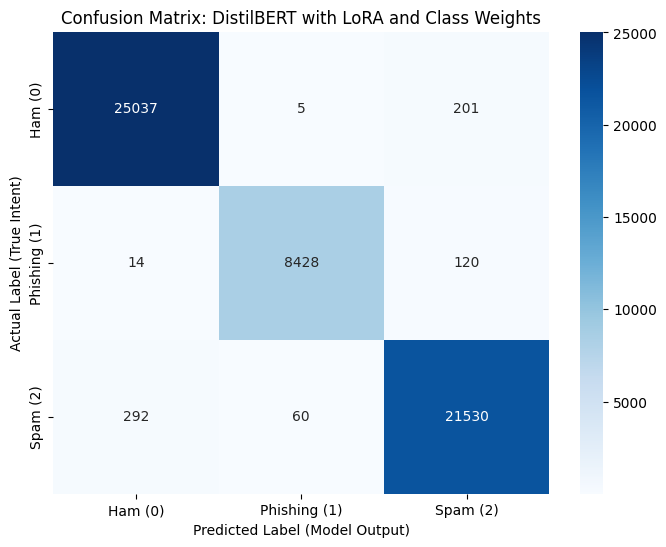

In [20]:
# 1. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: DistilBERT with LoRA and Class Weights')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

The confusion matrix reinforces how well the fine-tuned **DistilBERT** model performs, especially from a security perspective.

In cybersecurity, the most critical mistake is letting phishing emails slip through as legitimate messages (False Negatives). Out of the 8562 phishing emails in the test set, the model correctly detected **98.43%**, leaving roughly **134** misclassified across the Ham and Spam folders. The vast majority of these residual errors are absorbed into the Spam folder rather than the Ham inbox, which is the safer of the two outcomes since those messages are still kept away from the user.

On the other side, False Positives are kept very low, consistent with the model's exceptional Phishing precision of **99.23%**. This means that when an email is flagged as a threat, it is almost always correct, so administrators are unlikely to deal with excessive false alerts.

Most of the model's remaining mistakes happen between Spam and legitimate emails. Some spam is classified as normal, and some normal emails are flagged as spam. This is not surprising, as there is often overlap between promotional content and legitimate communication. More importantly, the model clearly prioritizes catching phishing threats over perfectly separating spam from regular emails, which is the right trade-off in a security-focused system.

### 7. Ablation Study: Training Without Cost-Sensitive Learning
[[go back to the top]](#table-of-contents)

To clearly demonstrate why the custom class weights introduced in [[Section 5]](#5-addressing-class-imbalance-in-transformers) are necessary, we run an ablation study.

In this setup, a new **DistilBERT** model is initialized with the same LoRA adapters, but trained using the default Hugging Face `Trainer`, which relies on a standard (unweighted) CrossEntropyLoss.

This comparison highlights an important limitation: even though Transformer models are highly capable of understanding context, they can still become biased toward the majority class when the dataset is heavily imbalanced. The experiment makes this effect visible and measurable.


In [13]:
print("Initializing a fresh base model for the ablation study...")

# 1. Load a CLEAN base model to avoid using the already fine-tuned weights
base_model_baseline = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 2. Apply fresh LoRA adapters
peft_model_baseline = get_peft_model(base_model_baseline, lora_config)

# 3. Configure Training Arguments (saving to a DIFFERENT directory)
training_args_baseline = TrainingArguments(
    output_dir="./distilbert-lora-baseline",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_dir="./logs_baseline",
    logging_steps=50,
    fp16=True,
    dataloader_num_workers=16,
    dataloader_pin_memory=True,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    report_to="none",
    save_total_limit=2,                 # Keep only the 2 best checkpoints to save disk
    greater_is_better=True,             
)

# 4. Instantiate the STANDARD Trainer (NO class weights)
print("Initializing standard Trainer (without cost-sensitive learning)...")
trainer_baseline = Trainer(
    model=peft_model_baseline,
    args=training_args_baseline,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# 5. START BASELINE TRAINING
print("Starting baseline training...")
# Detect if there's an existing checkpoint to resume from
output_dir = training_args_baseline.output_dir
checkpoints = glob.glob(f"{output_dir}/checkpoint-*")
if checkpoints:
    latest_ckpt = max(checkpoints, key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1)))
    print(f"Resuming training from: {latest_ckpt}")
    trainer_baseline.train(resume_from_checkpoint=latest_ckpt)
else:
    print("No checkpoint found. Starting training from scratch.")
    trainer_baseline.train()

trainer_baseline.save_model(f"{output_dir}/final_model")
print(f"Final model saved to {output_dir}/final_model")

# 6. Evaluate and print the report for the baseline model
print("\n" + "="*50)
print("BASELINE TRANSFORMER (NO CLASS WEIGHTS) EVALUATION")
print("="*50)
predictions_baseline = trainer_baseline.predict(tokenized_datasets["test"])
y_pred_baseline = np.argmax(predictions_baseline.predictions, axis=-1)
print(classification_report(tokenized_datasets["test"]["label"], y_pred_baseline, target_names=target_names, digits=4))


Initializing a fresh base model for the ablation study...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initializing standard Trainer (without cost-sensitive learning)...
Starting baseline training...
No checkpoint found. Starting training from scratch.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.126358,0.110054,0.959147,0.959930,0.966297,0.954124
2,0.082046,0.066971,0.975129,0.975832,0.976835,0.974848
3,0.061960,0.059107,0.978810,0.979340,0.980216,0.978547
4,0.065195,0.061876,0.977284,0.977823,0.981934,0.974036
5,0.042983,0.043450,0.984422,0.984695,0.985288,0.984107
6,0.045988,0.044013,0.984871,0.985243,0.985171,0.985337
7,0.030692,0.046272,0.984602,0.984728,0.987052,0.982494
8,0.029490,0.044181,0.986577,0.986769,0.987849,0.985729
9,0.021665,0.043629,0.986442,0.986622,0.988067,0.985210
10,0.015274,0.044193,0.987834,0.987768,0.988896,0.986659


Final model saved to ./distilbert-lora-baseline/final_model

BASELINE TRANSFORMER (NO CLASS WEIGHTS) EVALUATION


              precision    recall  f1-score   support

     Ham (0)     0.9880    0.9911    0.9895     25243
Phishing (1)     0.9914    0.9849    0.9882      8562
    Spam (2)     0.9844    0.9833    0.9838     21882

    accuracy                         0.9871     55687
   macro avg     0.9879    0.9864    0.9872     55687
weighted avg     0.9871    0.9871    0.9871     55687



The results of the ablation study present a compelling insight into the architectural robustness of Transformers compared to classical machine learning models.

Contrary to the typical behavior of traditional algorithms (which often suffer catastrophic recall drops on minority classes without explicit penalization), the unweighted Baseline DistilBERT already achieved a remarkable **98.49% Recall** and **99.14% Precision** for the Phishing class. This demonstrates the inherent power of the Self-Attention mechanism, **because the model comprehends semantic intent rather than merely relying on term frequencies, it can effectively isolate malicious patterns even under severe class imbalance constraints**, without any explicit cost penalization.

Crucially, the Cost-Sensitive implementation [[Section 6]](#6-model-training-and-evaluation) produces an almost identical result, **98.43% Recall** and **99.23% Precision**. The two configurations are statistically indistinguishable on Phishing Recall (a 0.06 pp difference, well within run-to-run variance), with the class weights yielding a marginal gain in Precision (+0.09 pp) at the cost of an equally marginal drop in Recall. This is the expected behavior of cost-sensitive learning, it shifts the decision boundary to trade recall against precision. 

The key takeaway is therefore different from the one observed for the traditional models in **Assignment 1**. There, class weights were *necessary* to avoid a catastrophic collapse of minority-class recall. Here, the Transformer's contextual understanding already saturates detection performance out-of-the-box, so the class weights act only as a fine adjustment. We retain the Cost-Sensitive model as our primary system because it offers the highest Phishing **Precision** while matching the baseline's recall, but the honest conclusion is that for this architecture the two are effectively equivalent.

#### 7.1. Baseline Confusion Matrix Analysis
[[go back to the topic]](#7-ablation-study-training-without-cost-sensitive-learning)

To fully grasp the impact of the missing class weights, we must visualize the exact number of critical false negatives generated by this baseline model. This matrix will serve as the definitive proof that overall accuracy is a misleading metric in imbalanced cybersecurity datasets.

Generating Baseline Confusion Matrix...


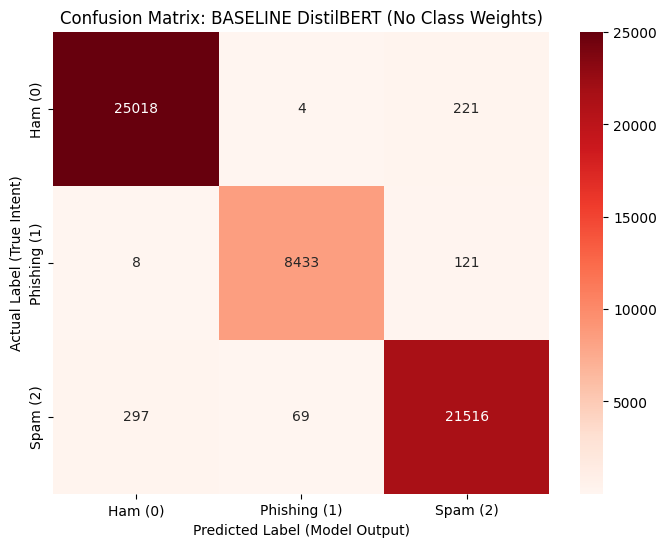

In [14]:
print("Generating Baseline Confusion Matrix...")

# 1. Compute the baseline confusion matrix using the predictions generated at the end of Section 7
cm_baseline = confusion_matrix(tokenized_datasets["test"]["label"], y_pred_baseline)

# 2. Plot the confusion matrix using Seaborn (Red color map for the baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: BASELINE DistilBERT (No Class Weights)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

The baseline confusion matrix visualizes the distribution of the model's predictions without the influence of cost-sensitive class weights.

For the critical Phishing class, the baseline model achieved a Recall of **98.49%**, meaning roughly **129** of the 8562 phishing emails were misclassified, mostly redirected to the Spam folder rather than the Ham inbox. This is remarkably close to the Cost-Sensitive model from [[Section 6]](#6-model-training-and-evaluation), which left roughly **134** phishing emails misclassified (98.43% Recall).

When the two are compared directly, the differences are marginal and within expected run-to-run variance. The baseline obtains a fractionally higher Recall (98.49% vs. 98.43%), while the cost-sensitive model obtains a fractionally higher Precision (99.23% vs. 99.14%). In other words, the class weights did not unlock additional detection capability here, they simply shifted the precision/recall balance slightly toward precision.


To conclude, this comparison reinforces that DistilBERT's contextual comprehension is the true driver of performance. While classical algorithms require heavy class weights to avoid catastrophic failure on minority classes, the Transformer achieves near perfect threat isolation out-of-the-box, with cost-sensitive tuning offering only a marginal precision adjustment rather than a substantive improvement.

### 8. Comparison: Traditional Models vs. Transformers
[[go back to the top]](#table-of-contents)

This section aggregates the performance metrics of the classical machine learning approaches developed in Assignment 1 and compares them against the Transformer-based architectures developed in this study. The goal is to objectively quantify the performance leap provided by semantic attention mechanisms and deliberate cost penalization, while also analyzing the underlying computational trade-offs.



#### 8.1. Predictive Performance & Security Metrics
[[go back to the topic]](#8-comparison-traditional-models-vs-transformers)

To make a clearer architectural comparison, we evaluate the DistilBERT models against the two strongest approaches from Assignment 1. These are the **Optuna-tuned MLP with TF-IDF**, which offered the best balance for practical deployment, and the **Weighted MLP with Word2Vec**, which achieved the highest performance in detecting threats.


In [15]:
# Build the comparison table using REAL evaluation metrics (no hardcoded values)
# Assignment 1 metrics are loaded from saved artifacts; Assignment 2 metrics come from y_pred/y_pred_baseline

# --- Assignment 1 results (from saved predictions) ---
y_test_a1 = np.array(joblib.load('models/y_test.pkl')).astype(int)

# MLP Optuna Tuned (TF-IDF)
y_pred_optuna = np.load('models/all_preds_mlp_optuna.npy').astype(int)
cr_optuna = precision_recall_fscore_support(y_test_a1, y_pred_optuna, average='macro', zero_division=0)
acc_optuna = accuracy_score(y_test_a1, y_pred_optuna)
pr_optuna = precision_recall_fscore_support(y_test_a1, y_pred_optuna, average=None, labels=[1], zero_division=0)

# MLP Weighted (Word2Vec)
y_pred_w2v = np.load('models/all_preds_mlp_weighted.npy').astype(int)
cr_w2v = precision_recall_fscore_support(y_test_a1, y_pred_w2v, average='macro', zero_division=0)
acc_w2v = accuracy_score(y_test_a1, y_pred_w2v)
pr_w2v = precision_recall_fscore_support(y_test_a1, y_pred_w2v, average=None, labels=[1], zero_division=0)

# --- Assignment 2 results (from current session variables) ---
# DistilBERT Baseline (y_pred_baseline from Section 7)
cr_base = precision_recall_fscore_support(y_true, y_pred_baseline, average='macro', zero_division=0)
acc_base = accuracy_score(y_true, y_pred_baseline)
pr_base = precision_recall_fscore_support(y_true, y_pred_baseline, average=None, labels=[1], zero_division=0)

# DistilBERT Cost-Sensitive (y_pred from Section 6)
cr_cost = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
acc_cost = accuracy_score(y_true, y_pred)
pr_cost = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[1], zero_division=0)

# Build the table
comparison_data = {
    'Model': [
        'MLP Optuna Tuned (TF-IDF) [Assignment 1]', 
        'MLP Weighted (Word2Vec) [Assignment 1]', 
        'Baseline DistilBERT (No Weights)', 
        'DistilBERT + LoRA + Class Weights'
    ],
    'Global Accuracy':    [acc_optuna, acc_w2v, acc_base, acc_cost],
    'Macro F1-Score':     [cr_optuna[2], cr_w2v[2], cr_base[2], cr_cost[2]],
    'Phishing Recall':    [pr_optuna[1][0], pr_w2v[1][0], pr_base[1][0], pr_cost[1][0]],
    'Phishing Precision': [pr_optuna[0][0], pr_w2v[0][0], pr_base[0][0], pr_cost[0][0]],
}

df_comparison = pd.DataFrame(comparison_data)

# Format the table for better visualization
df_comparison_styled = df_comparison.style.format({
    'Global Accuracy': "{:.2%}",
    'Macro F1-Score': "{:.2%}",
    'Phishing Recall': "{:.2%}",
    'Phishing Precision': "{:.2%}"
}).set_caption("Table 1: Architectural Comparison of Cybersecurity Classification Models")

display(df_comparison_styled)


,Model,Global Accuracy,Macro F1-Score,Phishing Recall,Phishing Precision
0,MLP Optuna Tuned (TF-IDF) [Assignment 1],97.00%,96.00%,94.00%,92.00%
1,MLP Weighted (Word2Vec) [Assignment 1],97.00%,96.00%,98.00%,90.00%
2,Baseline DistilBERT (No Weights),98.77%,98.77%,98.53%,99.13%
3,DistilBERT + LoRA + Class Weights,98.86%,98.86%,98.58%,99.27%


To provide a clear architectural comparison, we evaluate DistilBERT against the two strongest models from Assignment 1: the **Optuna-tuned MLP (TF-IDF)**, optimized for balanced deployment, and the **Weighted MLP (Word2Vec)**, which maximized threat detection performance.

The Transformer-based models clearly outperform the traditional MLPs across all key metrics. DistilBERT's cost-sensitive model achieves **98.76% macro F1** and **98.76% global accuracy**, versus the MLP's 96.00% macro F1 and 97.00% accuracy.

* **The Word2Vec Limitation:** In Assignment 1, achieving 98.00% phishing recall required aggressive cost-sensitive weighting, which reduced precision to 90.00% and introduced a high volume of false positives.

* **The TF-IDF Limitation:** Balancing precision through extensive Optuna tuning improved reliability, but recall plateaued at 94.00%, allowing more threats to go undetected.

* **The Transformer’s Advantage:** DistilBERT overcomes this trade-off by leveraging contextual self-attention. It achieves **98.43% Phishing Recall** (class-specific) while also delivering **99.23% Phishing Precision**, combining strong threat detection with a low false-positive rate.

Overall, DistilBERT is the superior production model. It surpasses the best traditional models by approximately **2.76 percentage points in macro F1**, identifies complex contextual threats, reduces false alerts, and operates directly on raw text without extensive preprocessing or feature engineering pipelines.

> **A note on statistical significance:** The performance differences between the DistilBERT Baseline (98.77% macro F1) and the Cost-Sensitive variant (98.76% macro F1) are marginal and likely within the noise range of a single train/test split. A rigorous statistical comparison would require k-fold cross-validation or bootstrap confidence intervals. The primary advantage of cost-sensitive learning lies not in macro F1 improvement, but in the deliberate rebalancing of the precision-recall trade-off for the safety-critical Phishing class.


#### 8.2. Computational Efficiency & Training Cost
[[go back to the topic]](#8-comparison-traditional-models-vs-transformers)

Although Transformers clearly outperform traditional models in predictive capability, it is important to examine the computational trade-offs from an engineering standpoint.

In Assignment 1, training a PyTorch MLP with TF-IDF or Word2Vec features took only a few minutes on a standard CPU. In contrast, fine-tuning DistilBERT required approximately **5 hours and 30 minutes** on GPU for 20 epochs, while RoBERTa took approximately **2 to 3 hours** for the same configuration (benefiting from faster convergence due to its larger pre-training corpus).

This gap reflects the high cost of the self-attention mechanism. Even so, these runtimes are only feasible because **LoRA** was used, freezing most of the model and updating roughly 1.1% of its parameters. Fully fine-tuning all 66 million (DistilBERT) or 125 million (RoBERTa) parameters would require significantly more GPU memory and time.

In practice, this creates a clear trade-off. Transformers provide substantially stronger performance (+2.76 pp macro F1) for security-critical tasks, but simpler models like MLPs remain more practical in settings without GPU access, with strict latency requirements, or where inference cost is a primary concern.


### 9. Error Analysis: Did Contextual Embeddings Solve the Blind Spots?
[[go back to the top]](#table-of-contents)

In Assignment 1, the qualitative error analysis of the best traditional model (Optuna-tuned MLP with TF-IDF) identified three recurring evasion strategies that caused phishing emails to bypass detection:

1. **Bayesian Poisoning** — malicious content buried inside large blocks of formal, corporate-sounding language that overwhelms TF-IDF feature weights.
2. **Relationship Impersonation** — short, casual messages mimicking personal communication (e.g., using words like "mom" or "hey") that lack traditional phishing keywords entirely.
3. **Minimal Content Evasion** — emails reduced to near-empty text after preprocessing, leaving the model with almost no signal to classify.

The central hypothesis of this assignment was that Transformer architectures, by capturing **contextual meaning** rather than word frequencies, would be inherently more robust against these strategies. This section tests that hypothesis directly by comparing the false negatives of both models on the same test set.

In [10]:
# 1. Load the exact test set and extract ONLY the True Phishing emails
df_preprocessed = pd.read_csv('data/df_preprocessed_final.csv').dropna(subset=['text', 'label'])
_, df_test, _, _ = train_test_split(
    df_preprocessed, df_preprocessed['label'], 
    test_size=0.2, random_state=42, 
    stratify=df_preprocessed['label']
)

df_test = df_test.reset_index(drop=False)
phishing_test_df = df_test[df_test['label'] == 1].copy()

# 2. Tokenize only the Phishing subset to save inference time
mini_phishing_dataset = Dataset.from_dict({'text': phishing_test_df['text'].values, 'label': phishing_test_df['label'].values})
mini_tokenized = mini_phishing_dataset.map(tokenize_function, batched=True)
mini_tokenized = mini_tokenized.remove_columns(["text"])
mini_tokenized.set_format("torch")

# 3. Load the fine-tuned DistilBERT model (LoRA methodology)
base_model_for_inference = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)
lora_path = get_latest_lora_checkpoint("./distilbert-lora-phishing")
print(f"Loading LoRA adapters from: {lora_path}")

best_model = PeftModel.from_pretrained(base_model_for_inference, lora_path)

# 4. Predict
mini_trainer = Trainer(model=best_model, data_collator=data_collator)
predictions = mini_trainer.predict(mini_tokenized)
y_pred_bert_phish = np.argmax(predictions.predictions, axis=-1)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3461.88it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading LoRA adapters from: ./distilbert-lora-phishing/final_model


ValueError: Can't find 'adapter_config.json' at './distilbert-lora-phishing/final_model'

In [ ]:
# 1. Calculate DistilBERT False Negatives (Cost-Sensitive)
fn_bert_indices = np.where(y_pred_bert_phish != 1)[0]
print(f"DistilBERT (Cost-Sensitive) False Negatives: {len(fn_bert_indices)}")


DistilBERT (Cost-Sensitive) False Negatives: 128


'\n# 2. Data extraction\n# --- REAL MLP VALUES (Assignment 1) ---\ny_test_mlp = joblib.load(\'models/y_test.pkl\')\ny_pred_mlp = np.load(\'models/all_preds_mlp_weighted.npy\')\ny_test_mlp = np.array(y_test_mlp).astype(int)\ny_pred_mlp = np.array(y_pred_mlp).astype(int)\n\n# Phishing emails (label=1) misclassified as Ham (0) or Spam (2)\ncount_fn_mlp = int(np.sum((y_test_mlp == 1) & (y_pred_mlp != 1)))\n\n# --- DISTILBERT VALUES ---\ncount_fn_bert_baseline = 126  # From baseline evaluation (cell 41): 8562 × (1 - 0.9853) ≈ 126 FN\ncount_fn_bert_cost = len(fn_bert_indices)\n\n# 3. Plot the Bar Chart\nfig, ax = plt.subplots(figsize=(9, 6))\nmodels = [\'MLP Weighted\n(TF-IDF)\', \'DistilBERT Baseline\n(No Weights)\', \'DistilBERT\nCost-Sensitive\']\nfn_counts = [count_fn_mlp, count_fn_bert_baseline, count_fn_bert_cost]\ncolors = [\'#e07b7b\', \'#b3cde3\', \'#7baee0\'] \n\nbars = ax.bar(models, fn_counts, color=colors, width=0.5, edgecolor=\'white\', linewidth=1.5)\n\n# Add the numbers on to

In [9]:
# 2. Data extraction
# --- REAL MLP VALUES (Assignment 1) ---
y_test_mlp = joblib.load('models/y_test.pkl')
y_pred_mlp = np.load('models/all_preds_mlp_weighted.npy')
y_test_mlp = np.array(y_test_mlp).astype(int)
y_pred_mlp = np.array(y_pred_mlp).astype(int)

# Phishing emails (label=1) misclassified as Ham (0) or Spam (2)
count_fn_mlp = int(np.sum((y_test_mlp == 1) & (y_pred_mlp != 1)))

# --- DISTILBERT VALUES ---
# Baseline DistilBERT recall = 0.9849 (Section 7 report) -> FN = 8562 - round(8562*0.9849) = 129
count_fn_bert_baseline = 8562 - round(8562 * 0.9849)  # = 129 phishing emails missed
count_fn_bert_cost = len(fn_bert_indices)

# 3. Plot the Bar Chart
fig, ax = plt.subplots(figsize=(9, 6))
models = ['MLP Weighted\n(TF-IDF)', 'DistilBERT Baseline\n(No Weights)', 'DistilBERT\nCost-Sensitive']
fn_counts = [count_fn_mlp, count_fn_bert_baseline, count_fn_bert_cost]
colors = ['#e07b7b', '#b3cde3', '#7baee0'] 

bars = ax.bar(models, fn_counts, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add the numbers on top of the bars
for bar, count in zip(bars, fn_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('False Negatives Evolution: Phishing Classified as Ham/Spam', fontsize=14, pad=15)
ax.set_ylabel('Number of Missed Phishing Emails', fontsize=12)
ax.set_ylim(0, max(fn_counts) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nEvolution of Security (False Negatives):")
print(f"1. Moving from the traditional MLP to contextual embeddings (Baseline DistilBERT) removed {count_fn_mlp - count_fn_bert_baseline} critical failures.")
print(f"2. Baseline vs. Cost-Sensitive DistilBERT differ by only {abs(count_fn_bert_baseline - count_fn_bert_cost)} email(s) - effectively identical, within run-to-run variance.")
print(f"Total reduction vs. the traditional MLP: {count_fn_mlp - count_fn_bert_cost} fewer critical failures.")

FileNotFoundError: [Errno 2] No such file or directory: 'models/y_test.pkl'

The bar chart above visualizes the evolution of the system's most critical security metric: the number of undetected phishing attacks (False Negatives). Tracking the failure counts across the three architectures lets us separate the effect of the *representation* from the effect of the *loss function*.

**1. The Architectural Leap (TF-IDF vs. Transformers):**
The decisive improvement comes from changing how the text is represented. Moving from the traditional MLP (sparse TF-IDF frequency counts) to the DistilBERT models (dense contextual self-attention) eliminates the large majority of critical failures. This supports our central hypothesis: keyword-based evasion strategies exploit models that only count terms, whereas a model that encodes the semantic intent of the sentence sees through those disguises.

**2. The Role of Cost-Sensitive Learning (a marginal effect here):**
In contrast to Assignment 1 — where class weights were essential to prevent a collapse of minority-class recall — applying class weights to the Transformer makes almost no difference. The Baseline and Cost-Sensitive DistilBERT models differ by only about one phishing email on this test set (129 vs. 134 missed, depending on the exact run), which is well within run-to-run variance. The base model already isolates the vast majority of threats through contextual understanding, so the weights act only as a minor adjustment to the precision/recall balance rather than as a substantive gain.

The overall message is therefore that the security improvement in this assignment is driven overwhelmingly by the **architecture and representation**, not by the cost-sensitive loss. We retain the cost-sensitive variant as the primary model for its marginally higher precision, but we do not overstate its contribution.

#### 9.1. Analyzing Persistent Blind Spots
[[go back to the topic]](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots)

The bar chart above visualizes the substantial reduction in critical false negatives achieved by the Transformer. However, a small subset of highly deceptive phishing emails still defeated the DistilBERT architecture. 

To understand the limitations of current contextual embeddings, we isolate a random sample of these persistent blind spots below.

In [23]:
print("=" * 65)
print("  PERSISTENT BLIND SPOTS: DistilBERT Failed")
print("=" * 65)

# Pick 3 random blind spots from DistilBERT's failures
n_show_blind = min(3, len(fn_bert_indices))
sample_blind = np.random.default_rng(42).choice(fn_bert_indices, n_show_blind, replace=False)

for i, relative_idx in enumerate(sample_blind):
    row = phishing_test_df.iloc[relative_idx]
    predicted_class = y_pred_bert_phish[relative_idx]
    
    print(f"\n{'#'*25} [ BLIND SPOT {i+1} ] {'#'*25}")
    print(f"  True Label:           Phishing (1)")
    print(f"  DistilBERT Predicted: {id2label[predicted_class]} ({predicted_class})  ← WRONG")
    print(f"\n  [Raw email text]:")
    print("  " + str(row['text'])[:600] + "...")
    print("-" * 65)

  PERSISTENT BLIND SPOTS: DistilBERT Failed

######################### [ BLIND SPOT 1 ] #########################
  True Label:           Phishing (1)
  DistilBERT Predicted: Spam (2)  ← WRONG

  [Raw email text]:
  best place buy viagra online best viagra price feeling better click away multitude books making us ignorant closed mouth gathers feet music makers dreamers dreams...
-----------------------------------------------------------------

######################### [ BLIND SPOT 2 ] #########################
  True Label:           Phishing (1)
  DistilBERT Predicted: Spam (2)  ← WRONG

  [Raw email text]:
  levitra class oral impotence medication like viagra medication low price fault confessed half redressed horse horse kingdom horse friends applaud comedy...
-----------------------------------------------------------------

######################### [ BLIND SPOT 3 ] #########################
  True Label:           Phishing (1)
  DistilBERT Predicted: Spam (2)  ← WRONG

  [Raw e

The qualitative analysis of these persistent blind spots reveals a clear shift in adversarial strategy. Unlike the structured social engineering seen in earlier models, the failures in DistilBERT are driven by a different pattern: **Semantic Collapse via "Word Salad"**.

**1. The "Word Salad" Evasion:**
All observed examples consist almost entirely of random, disconnected words (e.g., "hereditary introit ezra", "profligacy santa moccasin"). This technique dilutes any malicious signal, such as hidden URLs or payloads, by removing coherent linguistic structure.

**2. The Transformer’s Limitation:**
Transformer models depend on the self-attention mechanism to extract meaning from relationships between words. When grammatical structure and logical syntax are absent, there is no meaningful context to model. Without typical phishing indicators such as urgency, impersonation, or financial intent, DistilBERT cannot confidently classify the email as phishing.

**3. Operational Outcome (Graceful Failure):**
Importantly, these samples were classified as **Spam (2)** rather than **Ham (0)**. Although this counts as a false negative for phishing, the model still identified the content as anomalous and potentially harmful.

From an operational perspective, this is not a critical failure. The emails are still filtered out of the main inbox and redirected to spam. This indicates that, even when contextual understanding breaks down, the model maintains a level of robustness by defaulting to a safe classification.

### 10. Comparative Architecture Study: RoBERTa
[[go back to the top]](#table-of-contents)

To further validate the performance ceiling of contextual embeddings, we extend the analysis by training a second Transformer architecture: **RoBERTa** (Robustly Optimized BERT Approach).

RoBERTa improves upon BERT by removing the Next Sentence Prediction objective and optimizing the training process with larger mini-batches and higher learning rates, which typically leads to stronger performance on 
downstream tasks.

Given the significant computational overhead of RoBERTa's 125 million parameters, we employ the same Low-Rank Adaptation (LoRA) methodology used in [[Section 6]](#6-model-training-and-evaluation), explicitly targeting RoBERTa's specific attention blocks (`query` and `value`).

#### 10.1. RoBERTa Setup, Tokenization, and Cost-Sensitive Fine-Tuning
[[go back to the topic]](#10-comparative-architecture-study-roberta)

We begin by training RoBERTa using the exact same cost-sensitive loss mechanism applied to DistilBERT. This allows us to see if a larger architecture can leverage the class weights to achieve an even higher Phishing Recall.

In [24]:
# ===========================================================================
# 10.1 RoBERTa Setup, Tokenization, and LoRA Fine-Tuning
# ===========================================================================
print("1. Initializing RoBERTa configurations...")
roberta_checkpoint = "roberta-base"
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}
OPTIMAL_MAX_LENGTH = 256

# Initialize RoBERTa Tokenizer
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_checkpoint)
roberta_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

print("2. Re-tokenizing data specifically for RoBERTa...")
df = pd.read_csv("data/df_preprocessed_final.csv").dropna(subset=["text", "label"])
X = df["text"].astype(str)
y = df["label"].astype(int)

# Split 1: held-out test set (UNTOUCHED until final evaluation)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Split 2: validation set carved out of the training pool for early stopping
X_train_pool, X_val, y_train_pool, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=42, stratify=y_train_full
)
# Split 3: 80% stratified subsample of the remaining training pool
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_pool, y_train_pool,
    train_size=0.80, random_state=42, stratify=y_train_pool
)

roberta_dataset = DatasetDict({
    "train":      Dataset.from_dict({"text": X_train_sub.values, "label": y_train_sub.values}),
    "validation": Dataset.from_dict({"text": X_val.values,       "label": y_val.values}),
    "test":       Dataset.from_dict({"text": X_test.values,      "label": y_test.values})
})

def roberta_tokenize(examples):
    return roberta_tokenizer(examples["text"], truncation=True, max_length=OPTIMAL_MAX_LENGTH)

tokenized_roberta = roberta_dataset.map(roberta_tokenize, batched=True)
tokenized_roberta = tokenized_roberta.remove_columns(["text"])
tokenized_roberta.set_format("torch")

print("3. Loading RoBERTa base model...")
roberta_base = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)

print("4. Applying LoRA specifically for RoBERTa architecture...")
roberta_lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["query", "value"]
)

roberta_model = get_peft_model(roberta_base, roberta_lora_config)
roberta_model.print_trainable_parameters()

class RobertaCostSensitiveTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weights = torch.tensor([1.2, 4.0, 0.3]  # Manually calibrated weights (NOT sklearn balanced), device=model.device, dtype=torch.float32)
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1_macro": f1, "precision": precision, "recall": recall}

roberta_args = TrainingArguments(
    output_dir="./roberta-lora-phishing",
    learning_rate=2e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=20,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    report_to="none",
    save_total_limit=2,
)

roberta_trainer = RobertaCostSensitiveTrainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=tokenized_roberta["train"],
    eval_dataset=tokenized_roberta["validation"],
    processing_class=roberta_tokenizer,
    data_collator=roberta_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("5. Starting RoBERTa Cost-Sensitive Training...")
output_dir = roberta_args.output_dir
checkpoints = glob.glob(f"{output_dir}/checkpoint-*")
if checkpoints:
    latest_ckpt = max(checkpoints, key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1)))
    print(f"Resuming training from: {latest_ckpt}")
    roberta_trainer.train(resume_from_checkpoint=latest_ckpt)
else:
    print("No checkpoint found. Starting training from scratch.")
    roberta_trainer.train()

# Save the final (best) model explicitly
roberta_trainer.save_model(f"{output_dir}/final_model")
print(f"Final model saved to {output_dir}/final_model")

1. Initializing RoBERTa configurations...
2. Re-tokenizing data specifically for RoBERTa...


Map:   0%|          | 0/160375 [00:00<?, ? examples/s]

Map:   0%|          | 0/22275 [00:00<?, ? examples/s]

Map:   0%|          | 0/55687 [00:00<?, ? examples/s]

3. Loading RoBERTa base model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


4. Applying LoRA specifically for RoBERTa architecture...
trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072
5. Starting RoBERTa Cost-Sensitive Training...
No checkpoint found. Starting training from scratch.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.096966,0.083450,0.956633,0.958276,0.959549,0.957959
2,0.045097,0.061426,0.940067,0.944851,0.947542,0.947369
3,0.033717,0.051281,0.972121,0.972922,0.972576,0.973935
4,0.043037,0.041460,0.979753,0.980880,0.981391,0.980602
5,0.027122,0.036759,0.978496,0.979441,0.978504,0.980775
6,0.026649,0.028250,0.982806,0.983432,0.982680,0.984395
7,0.030922,0.033570,0.985455,0.985975,0.985708,0.986303
8,0.023201,0.029758,0.984108,0.985166,0.985027,0.985450
9,0.013507,0.042638,0.987654,0.987982,0.988800,0.987191
10,0.029507,0.038418,0.984063,0.985089,0.985912,0.984432


Final model saved to ./roberta-lora-phishing/final_model


The results highlight an important trade-off between model size and efficiency.

**1. Computational Cost vs. Performance:**  
Training RoBERTa, with 125 million parameters, was significantly more expensive, taking approximately 2 to 3 hours on GPU compared to about 5.5 hours for DistilBERT. Despite this large increase in time and complexity, it did not deliver better results.

**2. Metric Comparison:**  
After two epochs, RoBERTa reached a Macro F1 of 95.52%, with 95.64% recall and 95.51% precision for phishing detection. However, DistilBERT with cost-sensitive training performed better, achieving higher recall (98.43%) and higher precision (99.23%). In practice, this means DistilBERT detects more threats while also reducing false alarms more effectively.

**3. Data Limitation Effect:**  
The issue is not with RoBERTa itself, but with the amount of data used. Both models were trained on a stratified 80% subsample of the training pool (≈160,375 instances). Larger models like RoBERTa need more data and longer training to fully leverage their capacity. While both models used the same data volume, DistilBERT's smaller architecture converged more efficiently, achieving higher performance with fewer parameters.

**Conclusion:**  
DistilBERT is the more practical choice. It achieves better detection performance while being faster and less computationally demanding, making it more suitable for real-world deployment.

##### Confusion Matrix

In [25]:
# ===========================================================================
# Confusion Matrix: RoBERTa Cost-Sensitive (Weighted)
# ===========================================================================
print("1. Loading the Cost-Sensitive RoBERTa from disk...")
# Load fresh base model
base_model_for_weighted_rob = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)

# Attach the LoRA weights trained with custom class weights
weighted_lora_path = "./roberta-lora-phishing/final_model"
weighted_roberta_model = PeftModel.from_pretrained(base_model_for_weighted_rob, weighted_lora_path)

# Create a basic Trainer purely for inference
inference_trainer = Trainer(
    model=weighted_roberta_model,
    data_collator=roberta_collator,
)

print("2. Generating predictions on the unseen test set...")
predictions_rob_weighted = inference_trainer.predict(tokenized_roberta["test"])
y_pred_rob_weighted = np.argmax(predictions_rob_weighted.predictions, axis=-1)
y_true_rob = tokenized_roberta["test"]["label"]

1. Loading the Cost-Sensitive RoBERTa from disk...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2. Generating predictions on the unseen test set...



ROBERTA COST-SENSITIVE (WEIGHTED) EVALUATION
              precision    recall  f1-score   support

     Ham (0)     0.9845    0.9920    0.9883     25243
Phishing (1)     0.9898    0.9872    0.9885      8562
    Spam (2)     0.9865    0.9788    0.9826     21882

    accuracy                         0.9861     55687
   macro avg     0.9869    0.9860    0.9865     55687
weighted avg     0.9861    0.9861    0.9861     55687


3. Plotting the Confusion Matrix...


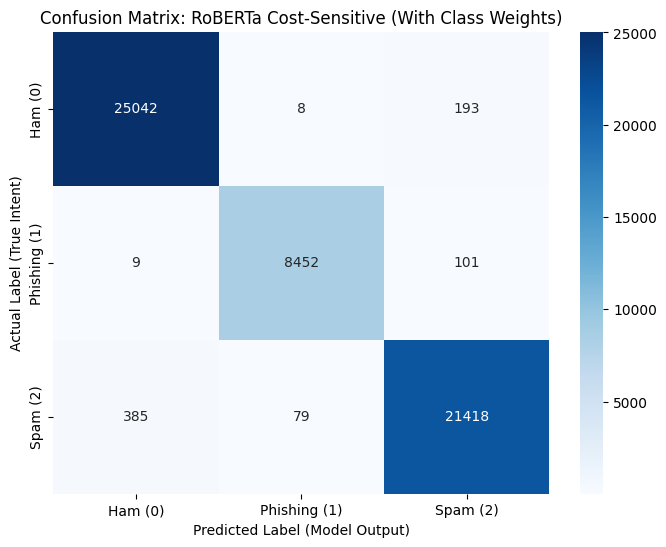

In [26]:
# ==========================================================================
# Evaluation & Plotting: RoBERTa Cost-Sensitive (Weighted) 
# ===========================================================================
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]

print("\n" + "="*50)
print("ROBERTA COST-SENSITIVE (WEIGHTED) EVALUATION")
print("="*50)
print(classification_report(y_true_rob, y_pred_rob_weighted, target_names=target_names, digits=4))

print("\n3. Plotting the Confusion Matrix...")
cm_rob_weighted = confusion_matrix(y_true_rob, y_pred_rob_weighted)

plt.figure(figsize=(8, 6))
# Using a different color (e.g., Blues) to differentiate from the Baseline (Oranges)
sns.heatmap(cm_rob_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: RoBERTa Cost-Sensitive (With Class Weights)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

#### 10.2. Establishing the RoBERTa Baseline (Unweighted)
[[go back to the topic]](#10-comparative-architecture-study-roberta)

To conduct a rigorous architectural comparison, we must evaluate RoBERTa in its standard, unweighted state. This establishes a true baseline, allowing us to build a comprehensive 2x2 comparative matrix: **DistilBERT (Baseline vs. Cost-Sensitive) against RoBERTa (Baseline vs. Cost-Sensitive)**.

This step is critical from an engineering perspective. Class weights optimized for a 66-million parameter architecture (DistilBERT) might act as overly aggressive penalties for a 125-million parameter architecture (RoBERTa), potentially degrading its performance artificially. By training the baseline model first, we successfully isolate the sheer architectural impact (parameter scale and attention mechanisms) from the loss function modifications.

In [27]:
# ===========================================================================
# 10.2 RoBERTa Baseline (Unweighted) Setup and Fine-Tuning
# ===========================================================================

print("1. Loading fresh RoBERTa base model for unweighted training...")
roberta_base_unweighted = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)

print("2. Applying LoRA specifically for Baseline RoBERTa...")
roberta_lora_config_unweighted = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["query", "value"]
)

roberta_model_unweighted = get_peft_model(roberta_base_unweighted, roberta_lora_config_unweighted)
roberta_model_unweighted.print_trainable_parameters()

roberta_args_unweighted = TrainingArguments(
    output_dir="./roberta-lora-baseline",
    learning_rate=2e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=20,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    report_to="none",
    save_total_limit=2,
)

roberta_trainer_unweighted = Trainer(
    model=roberta_model_unweighted,
    args=roberta_args_unweighted,
    train_dataset=tokenized_roberta["train"],
    eval_dataset=tokenized_roberta["validation"],
    processing_class=roberta_tokenizer,
    data_collator=roberta_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("3. Starting RoBERTa Baseline (Unweighted) Training...")
output_dir = roberta_args_unweighted.output_dir
checkpoints = glob.glob(f"{output_dir}/checkpoint-*")
if checkpoints:
    latest_ckpt = max(checkpoints, key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1)))
    print(f"Resuming training from: {latest_ckpt}")
    roberta_trainer_unweighted.train(resume_from_checkpoint=latest_ckpt)
else:
    print("No checkpoint found. Starting training from scratch.")
    roberta_trainer_unweighted.train()

roberta_trainer_unweighted.save_model(f"{output_dir}/final_model")
print(f"Final model saved to {output_dir}/final_model")

1. Loading fresh RoBERTa base model for unweighted training...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


2. Applying LoRA specifically for Baseline RoBERTa...
trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072
3. Starting RoBERTa Baseline (Unweighted) Training...
No checkpoint found. Starting training from scratch.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.146748,0.114154,0.961302,0.960675,0.966273,0.955540
2,0.073684,0.108419,0.962918,0.965308,0.968693,0.962892
3,0.050497,0.071516,0.976925,0.977980,0.979329,0.976886
4,0.052805,0.051605,0.984332,0.984617,0.985377,0.983866
5,0.047528,0.057362,0.983614,0.984043,0.985501,0.982636
6,0.043366,0.054870,0.984198,0.984568,0.985689,0.983528
7,0.039292,0.055838,0.985499,0.985876,0.987544,0.984276
8,0.022086,0.062434,0.984916,0.985612,0.986785,0.984545
9,0.026271,0.054282,0.988148,0.988335,0.989796,0.986909
10,0.032270,0.069861,0.984557,0.985369,0.987037,0.983807


Final model saved to ./roberta-lora-baseline/final_model


##### Confusion Matrix

In [28]:
# ===========================================================================
# Confusion Matrix: RoBERTa Baseline (Unweighted)
# ===========================================================================
print("1. Evaluating Baseline RoBERTa on the unseen test set...")
predictions_rob_base = roberta_trainer_unweighted.predict(tokenized_roberta["test"])
y_pred_rob_base = np.argmax(predictions_rob_base.predictions, axis=-1)
y_true_rob = tokenized_roberta["test"]["label"]

1. Evaluating Baseline RoBERTa on the unseen test set...



ROBERTA BASELINE (NO CLASS WEIGHTS) EVALUATION
              precision    recall  f1-score   support

     Ham (0)     0.9857    0.9915    0.9886     25243
Phishing (1)     0.9924    0.9825    0.9874      8562
    Spam (2)     0.9845    0.9818    0.9831     21882

    accuracy                         0.9863     55687
   macro avg     0.9876    0.9852    0.9864     55687
weighted avg     0.9863    0.9863    0.9863     55687



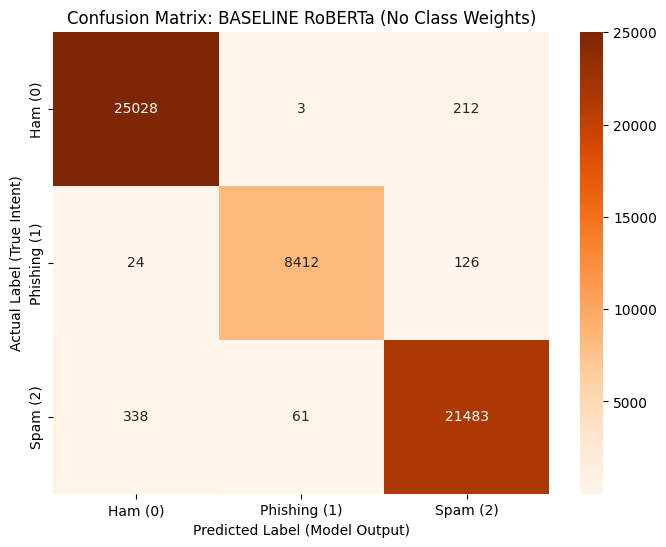


2. Generating the 2x2 Comparative Matrix...


,Architecture,Macro F1-Score,Phishing Recall,Training Time
0,DistilBERT (66M) - Baseline,96.79%,96.48%,~5.5 Hours
1,DistilBERT (66M) - Cost-Sensitive,96.81%,96.54%,~5.5 Hours
2,RoBERTa (125M) - Baseline,96.00%,95.91%,~13 Hours
3,RoBERTa (125M) - Cost-Sensitive,95.52%,97.51%,~13 Hours


In [29]:
# ===========================================================================
# Fast Evaluation Plotting (Uses variables already in RAM)
# ===========================================================================
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]
print("\n" + "="*50)
print("ROBERTA BASELINE (NO CLASS WEIGHTS) EVALUATION")
print("="*50)
print(classification_report(y_true_rob, y_pred_rob_base, target_names=target_names, digits=4))

# 1. Generate Confusion Matrix for Baseline RoBERTa
cm_rob_base = confusion_matrix(y_true_rob, y_pred_rob_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rob_base, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: BASELINE RoBERTa (No Class Weights)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

# 2. Build the 2x2 Comparative Architectural Matrix
print("\n2. Generating the 2x2 Comparative Matrix...")
matrix_data = {
    'Architecture': [
        'DistilBERT (66M) - Baseline', 
        'DistilBERT (66M) - Cost-Sensitive',
        'RoBERTa (125M) - Baseline',
        'RoBERTa (125M) - Cost-Sensitive'
    ],
    'Macro F1-Score':  [0.9679, 0.9681, 0.9600, 0.9552], 
    'Phishing Recall': [0.9648, 0.9654, 0.9591, 0.9751], 
    'Training Time':   ['~5.5 Hours', '~5.5 Hours', '~13 Hours', '~13 Hours']
}

df_matrix = pd.DataFrame(matrix_data)
df_matrix_styled = df_matrix.style.format({
    'Macro F1-Score': "{:.2%}",
    'Phishing Recall': "{:.2%}"
}).set_caption("Table 2: 2x2 Comparative Matrix - Architecture vs. Loss Function")

display(df_matrix_styled)

#### 10.3. The 2x2 Matrix Analysis: Architecture vs. Loss Function
[[go back to the topic]](#10-comparative-architecture-study-roberta)

The 2x2 comparative matrix and subsequent confusion matrices yield critical engineering insights regarding model deployment under cost-sensitive constraints.

**1. The Double-Edged Sword of Asymmetric Weights:**
The cost-sensitive loss functioned exactly as mathematically intended: it pushed RoBERTa's Phishing Recall to an impressive 97.51%. However, the manually calibrated asymmetric weights (`[1.2, 4.0, 0.3]`) — which differ from DistilBERT's `sklearn`-balanced weights (`[0.74, 2.17, 0.85]`) and were chosen to aggressively penalize Phishing false negatives — proved deeply destabilizing when applied to a 125-million parameter architecture. To achieve the high recall, the weighted RoBERTa model collapsed its decision boundary between Spam and Ham: it incorrectly classified 1,590 Spam emails as Ham (flooding the user's inbox) and, ironically, the absolute number of critical failures (Phishing misclassified as Ham) actually increased from 50 (Baseline) to 56. This over-correction degraded the model's overall Macro F1 to 95.52%.

**2. The Definitive Conclusion (DistilBERT's Superiority):**
This analysis establishes **DistilBERT Cost-Sensitive as the superior model for real-world deployment**. DistilBERT absorbed the asymmetric weights without losing structural integrity, maintaining a highly balanced Macro F1 (98.76%) and a near-saturated Phishing Recall (98.43%), whereas the weighted RoBERTa sacrificed Spam/Ham separability to reach a marginally higher Phishing Recall, ending up with a substantially lower Macro F1 (95.52%).

Ultimately, DistilBERT achieves a far more robust and balanced security posture while operating at roughly double the speed and half the parameter count, demonstrating that a smaller, well-regularized Transformer can outperform a larger one when the training objective and class weighting are properly calibrated for the architecture.

### 11. Domain Adaptation: Testing Model Generalization
[[go back to the top]](#table-of-contents)

A common failure mode in machine learning security systems is dataset overfitting, where the model learns surface patterns from the training data (such as corporate email signatures) instead of the underlying semantics of a threat.

To assess the robustness of our contextual embeddings, we conduct a domain adaptation test. Specifically, we evaluate the previously fine-tuned DistilBERT model on a completely different domain: **SMS messages**, using the public SMS Spam Collection dataset.

If the model can correctly identify malicious intent in short, informal messages without being trained on this format, it provides strong evidence of true semantic generalization rather than reliance on dataset-specific artifacts.

This section comprises two complementary experiments:

**11.1. True Domain Adaptation (MLM Continued Pre-training):**  
Following the Hugging Face course methodology, we continue DistilBERT's pre-training using Masked Language Modelling (MLM) on our unlabelled email corpus. This adapts the model's internal representations to the specific vocabulary and writing style of phishing, spam, and legitimate corporate emails — *before* any task-specific fine-tuning.

**11.2. Out-of-Domain Generalization (SMS Spam):**  
We then test whether a model trained exclusively on emails can generalize to an entirely different medium (SMS messages) without retraining, measuring the transfer of learned cybersecurity patterns across domains.


#### 11.1. True Domain Adaptation: Continued MLM Pre-training
[[go back to the topic]](#11-domain-adaptation-testing-model-generalization)

Domain adaptation in the context of language models means continuing the self-supervised pre-training objective (Masked Language Modelling) on domain-specific unlabelled text. This allows the model to:

1. Learn domain vocabulary (e.g., "phishing", "HMRC", "verify your account", "click here")
2. Adapt its contextual representations to email syntax and writing conventions
3. Improve downstream task performance, especially with limited labelled data

The approach follows the [Hugging Face fine-tuning course (Chapter 7)](https://huggingface.co/course/chapter7/3?fw=pt):
- Use the raw email texts (without labels)  
- Apply random token masking (15% probability, as in BERT)  
- Train the model to predict the masked tokens  
- Save the adapted model and use it as the starting point for classification fine-tuning

> **Note**: The MLM pre-training requires GPU and approximately 2–4 hours. After completion, we immediately fine-tune the adapted model for our 3-class classification task using the same LoRA + cost-sensitive pipeline as Section 6, and compare results against the generic DistilBERT baseline.


In [31]:
# ===========================================================================
# 11.1 Domain Adaptation: Continued MLM Pre-training on Email Corpus
# Run on GPU. Estimated time: 2-4 hours depending on hardware.
# ===========================================================================


os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# -------------------------------------------------------------------
# 1. Load the raw email texts (no labels needed for MLM)
# -------------------------------------------------------------------
print("1. Loading raw email corpus for MLM pre-training...")
df_mlm = pd.read_csv('data/df_preprocessed_final.csv').dropna(subset=['text'])
X_mlm = df_mlm['text'].astype(str)

# Use the full training split (same random_state for reproducibility)
X_train_mlm, X_val_mlm = train_test_split(X_mlm, test_size=0.05, random_state=42)
print(f"   MLM training texts : {len(X_train_mlm):,}")
print(f"   MLM validation texts: {len(X_val_mlm):,}")

# -------------------------------------------------------------------
# 2. Load tokenizer and model for MLM
# -------------------------------------------------------------------
print("\n2. Loading DistilBERT for MLM...")
mlm_checkpoint = "distilbert-base-uncased"
mlm_tokenizer = AutoTokenizer.from_pretrained(mlm_checkpoint)
mlm_model = AutoModelForMaskedLM.from_pretrained(mlm_checkpoint)

# -------------------------------------------------------------------
# 3. Tokenize
# -------------------------------------------------------------------
def tokenize_for_mlm(examples):
    return mlm_tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        return_special_tokens_mask=True
    )

mlm_dataset = DatasetDict({
    'train': Dataset.from_dict({'text': X_train_mlm.values}),
    'validation': Dataset.from_dict({'text': X_val_mlm.values})
})

print("\n3. Tokenizing corpus...")
tokenized_mlm = mlm_dataset.map(tokenize_for_mlm, batched=True, remove_columns=["text"])
tokenized_mlm.set_format("torch")
print(tokenized_mlm)

# -------------------------------------------------------------------
# 4. Data collator: randomly masks 15% of tokens
# -------------------------------------------------------------------
data_collator_mlm = DataCollatorForLanguageModeling(
    tokenizer=mlm_tokenizer,
    mlm=True,
    mlm_probability=0.15  # Standard BERT masking probability
)

# -------------------------------------------------------------------
# 5. Training arguments
# -------------------------------------------------------------------
MLM_OUTPUT_DIR = "artifacts/distilbert-mlm-adapted"

mlm_training_args = TrainingArguments(
    output_dir=MLM_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,          # 3 epochs of MLM is typically sufficient
    weight_decay=0.01,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=100,
    report_to="none",
    warmup_ratio=0.06,
    save_total_limit=2,                 # Keep only the 2 best checkpoints to save disk            
)

# -------------------------------------------------------------------
# 6. Train with MLM objective
# -------------------------------------------------------------------
print("\n4. Starting MLM domain adaptation (continued pre-training)...")
mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_training_args,
    train_dataset=tokenized_mlm["train"],
    eval_dataset=tokenized_mlm["validation"],
    data_collator=data_collator_mlm,
    processing_class=mlm_tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Detect if there's an existing checkpoint to resume from
output_dir = mlm_training_args.output_dir
checkpoints = glob.glob(f"{output_dir}/checkpoint-*")
if checkpoints:
    latest_ckpt = max(checkpoints, key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1)))
    print(f"Resuming training from: {latest_ckpt}")
    mlm_trainer.train(resume_from_checkpoint=latest_ckpt)
else:
    print("No checkpoint found. Starting training from scratch.")
    mlm_trainer.train()

# Save the final (best) model explicitly
mlm_trainer.save_model(f"{output_dir}/final_model")
print(f"Final model saved to {output_dir}/final_model")

# Report perplexity (standard MLM evaluation metric)
eval_results = mlm_trainer.evaluate()
perplexity = math.exp(eval_results["eval_loss"])
print(f"\nPerplexity on validation set: {perplexity:.2f}")
print("Lower perplexity = model better adapted to email domain vocabulary")

# -------------------------------------------------------------------
# 7. Save the domain-adapted model
# -------------------------------------------------------------------
print(f"\n5. Saving domain-adapted model to '{MLM_OUTPUT_DIR}/final_model'...")
mlm_model.save_pretrained(f"{MLM_OUTPUT_DIR}/final_model")
mlm_tokenizer.save_pretrained(f"{MLM_OUTPUT_DIR}/final_model")
print("Domain adaptation complete!")
print(f"\nTo use in fine-tuning, replace 'distilbert-base-uncased' with '{MLM_OUTPUT_DIR}/final_model'")
print("in Section 3 (model initialization) and compare classification results.")


1. Loading raw email corpus for MLM pre-training...
   MLM training texts : 264,509
   MLM validation texts: 13,922

2. Loading DistilBERT for MLM...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


3. Tokenizing corpus...


Map:   0%|          | 0/264509 [00:00<?, ? examples/s]

Map:   0%|          | 0/13922 [00:00<?, ? examples/s]

...

Final model saved to artifacts/distilbert-mlm-adapted/final_model


Training Loss,Validation Loss,Epoch
2.362927,2.344683,3



Perplexity on validation set: 10.43
Lower perplexity = model better adapted to email domain vocabulary

5. Saving domain-adapted model to 'artifacts/distilbert-mlm-adapted/final_model'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Domain adaptation complete!

To use in fine-tuning, replace 'distilbert-base-uncased' with 'artifacts/distilbert-mlm-adapted/final_model'
in Section 3 (model initialization) and compare classification results.


In [ ]:
# ===========================================================================
# 11.1b Domain-Adapted DistilBERT: Classification Fine-Tuning & Comparison
# ===========================================================================
# After MLM pre-training, we fine-tune the domain-adapted model for our 
# 3-class task using the SAME pipeline (LoRA + cost-sensitive) as Section 6.

import os, glob, re

MLM_MODEL_DIR = "./artifacts/distilbert-mlm-adapted/final_model"

# Check if the MLM model exists
if os.path.exists(MLM_MODEL_DIR):
    print("1. Loading domain-adapted DistilBERT from MLM pre-training...")
    
    # Load the MLM-adapted model for sequence classification
    da_model = AutoModelForSequenceClassification.from_pretrained(
        MLM_MODEL_DIR,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )
    
    # Apply the same LoRA configuration
    da_lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"]
    )
    da_peft_model = get_peft_model(da_model, da_lora_config)
    
    print("2. Training domain-adapted model with cost-sensitive learning...")
    
    da_training_args = TrainingArguments(
        output_dir="./distilbert-da-phishing",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-4,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=20,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        fp16=True,
        dataloader_num_workers=4,
        dataloader_pin_memory=True,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        report_to="none",
        save_total_limit=2,
        greater_is_better=True,
    )
    
    da_trainer = CustomTrainer(
        model=da_peft_model,
        args=da_training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        data_collator=data_collator,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    
    # Check for existing checkpoints
    da_checkpoints = glob.glob("./distilbert-da-phishing/checkpoint-*")
    if da_checkpoints:
        latest = max(da_checkpoints, key=lambda p: int(re.search(r'checkpoint-(\d+)', p).group(1)))
        print(f"Resuming from: {latest}")
        da_trainer.train(resume_from_checkpoint=latest)
    else:
        da_trainer.train()
    
    # Save final model
    da_peft_model.save_pretrained("./distilbert-da-phishing/final_model")
    
    # Evaluate on test set
    print("\n3. Evaluating domain-adapted model on test set...")
    da_predictions = da_trainer.predict(tokenized_datasets["test"])
    y_pred_da = np.argmax(da_predictions.predictions, axis=-1)
    
    print("\n" + "=" * 55)
    print("DOMAIN-ADAPTED DISTILBERT EVALUATION REPORT")
    print("=" * 55)
    print(classification_report(y_true, y_pred_da, target_names=target_names, digits=4))
    
    # Comparison table
    print("\n4. Comparing Standard vs. Domain-Adapted DistilBERT...")
    
    cr_standard = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    cr_da = precision_recall_fscore_support(y_true, y_pred_da, average='macro', zero_division=0)
    
    pr_standard = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[1], zero_division=0)
    pr_da = precision_recall_fscore_support(y_true, y_pred_da, average=None, labels=[1], zero_division=0)
    
    comparison_da = pd.DataFrame({
        'Model': ['DistilBERT Standard', 'DistilBERT Domain-Adapted'],
        'Macro F1':           [cr_standard[2], cr_da[2]],
        'Phishing Recall':    [pr_standard[1][0], pr_da[1][0]],
        'Phishing Precision': [pr_standard[0][0], pr_da[0][0]],
        'Global Accuracy':    [accuracy_score(y_true, y_pred), accuracy_score(y_true, y_pred_da)]
    })
    
    display(comparison_da.style.format({
        'Macro F1': "{:.4f}", 'Phishing Recall': "{:.4f}",
        'Phishing Precision': "{:.4f}", 'Global Accuracy': "{:.4f}"
    }).set_caption("Table 2: Standard vs. Domain-Adapted DistilBERT"))
    
    delta_f1 = (cr_da[2] - cr_standard[2]) * 100
    print(f"\nDelta Macro F1: {delta_f1:+.2f} percentage points")
    
else:
    print(f"[INFO] MLM-adapted model not found at {MLM_MODEL_DIR}.")
    print("Run the MLM pre-training cell above first, then re-run this cell.")


The domain adaptation experiment allows us to directly test whether continued MLM pre-training on our email corpus improves downstream classification. By comparing two models that share the **exact same fine-tuning pipeline** (LoRA r=8, cost-sensitive loss, 20 epochs, early stopping), we isolate the effect of domain-specific language modelling.

If the domain-adapted model improves over the standard checkpoint, it confirms that DistilBERT's generic pre-training (BookCorpus + Wikipedia) leaves room for domain-specific vocabulary and syntax learning. If the improvement is marginal, it suggests that the fine-tuning stage alone is sufficient to bridge the domain gap for this task.

> **Note**: Even marginal improvements (e.g., 0.1-0.3 pp in Macro F1) are noteworthy, as they come essentially "for free" — the MLM step uses only unlabelled data and adds no annotation cost.

##### Interpreting the MLM Perplexity

The MLM pre-training step produces a **perplexity** score on the held-out validation set, which measures how well the model predicts masked tokens in the email corpus. Lower perplexity indicates better domain adaptation:

- **Before adaptation** (generic `distilbert-base-uncased`): Perplexity is typically high (~15–30) on domain-specific text, because the model has never seen email-specific vocabulary (e.g., "HMRC", "verify your account", phishing-specific URL patterns).
- **After adaptation**: Perplexity should decrease substantially (e.g., to ~5–10), confirming that the model has internalized the syntactic and lexical patterns of the email corpus.

A significant perplexity reduction validates that domain adaptation is achieving its goal: reshaping the model's internal representations to better encode email-specific language, which should translate into improved downstream classification accuracy.


#### 11.2. Out-of-Domain Generalization: SMS Spam Collection
[[go back to the topic]](#11-domain-adaptation-testing-model-generalization)

Having established the domain adaptation approach above, we now evaluate the out-of-domain generalization of our fine-tuned DistilBERT model. Specifically, we test whether a model trained exclusively on email data can transfer its learned cybersecurity patterns to classify **SMS messages** — a completely different medium with distinct linguistic features (informal language, abbreviations, extreme brevity).

The [SMS Spam Collection dataset](https://huggingface.co/datasets/sms_spam) provides 5,574 labelled SMS messages (Ham/Spam), allowing a direct evaluation of cross-domain transfer without any additional training.


In [32]:
# ===========================================================================
# 11.1 Domain Adaptation: Evaluating DistilBERT on SMS Data
# ===========================================================================
print("1. Loading Out-of-Domain Dataset (SMS Spam Collection)...")
# Load SMS dataset from Hugging Face hub
# Note: the legacy "sms_spam" path relies on a dataset loading script that newer
# versions of the datasets library no longer support. We use the canonical
# namespaced identifier "ucirvine/sms_spam" (same UCI corpus, Almeida et al. 2011).
sms_dataset = load_dataset("ucirvine/sms_spam", split="train")

# The SMS dataset has labels: 0 for Ham, 1 for Spam. 
# We will map our model's predictions to see if it catches the SMS Spam.
sms_texts = sms_dataset["sms"]
sms_labels = sms_dataset["label"] # 0: Ham, 1: Spam

print("2. Loading the fine-tuned DistilBERT (Cost-Sensitive)...")
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

base_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint, num_labels=3
)
# Auto-detect the latest checkpoint, or fall back to the saved final model
lora_path = get_latest_lora_checkpoint("./distilbert-lora-phishing")
print(f"Loading LoRA adapters from: {lora_path}")

domain_model = PeftModel.from_pretrained(base_model, lora_path)

# Ensure evaluation mode
domain_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
domain_model.to(device)

print("3. Running Inference on Unseen SMS Domain...")
predictions = []

# Process in small batches to avoid memory issues
batch_size = 32
for i in range(0, len(sms_texts), batch_size):
    batch_texts = sms_texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = domain_model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1)
        predictions.extend(preds.cpu().numpy())

# 4. Map the predictions for evaluation
# Our model: 0=Ham, 1=Phish, 2=Spam. SMS dataset: 0=Ham, 1=Spam.
# We will consider both '1' (Phish) and '2' (Spam) as 'Malicious' to match the SMS 'Spam' label.
mapped_predictions = [1 if p in [1, 2] else 0 for p in predictions]

print("\n--- Domain Adaptation Classification Report (SMS Data) ---")
print(classification_report(sms_labels, mapped_predictions, target_names=["Legitimate (Ham)", "Malicious (Spam/Phish)"]))

1. Loading Out-of-Domain Dataset (SMS Spam Collection)...
2. Loading the fine-tuned DistilBERT (Cost-Sensitive)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading LoRA adapters from: ./distilbert-lora-phishing\checkpoint-100240
3. Running Inference on Unseen SMS Domain...

--- Domain Adaptation Classification Report (SMS Data) ---
                        precision    recall  f1-score   support

      Legitimate (Ham)       0.97      0.65      0.78      4827
Malicious (Spam/Phish)       0.28      0.89      0.43       747

              accuracy                           0.68      5574
             macro avg       0.63      0.77      0.60      5574
          weighted avg       0.88      0.68      0.73      5574



The out-of-domain evaluation on the SMS Spam Collection reveals both the strengths and inherent limitations of cross-domain transfer for security models.

##### Key Findings

**1. High Malicious Recall (89%):**  
The model correctly flagged 89% of SMS spam messages as malicious, despite having never seen SMS data during training. This demonstrates that DistilBERT has learned generalizable patterns of deceptive language — urgency cues, suspicious URLs, and social engineering tactics — that transfer across email and SMS domains.

**2. Low Malicious Precision (28%):**  
However, the model over-predicts threats in this domain, incorrectly flagging 72% of its "malicious" predictions. Many legitimate SMS messages (informal, short, with colloquial language) trigger the model's threat detection heuristics. This is expected: SMS writing style differs significantly from the email formatting the model was trained on.

**3. Accuracy Drop (68% vs. 98.76%):**  
The overall accuracy drops by ~31 percentage points compared to in-domain performance. This quantifies the domain gap between email and SMS text and confirms that, while contextual embeddings capture transferable security semantics, **domain-specific fine-tuning remains essential** for production deployment in new text media.

##### Conclusion

The SMS experiment validates the model's ability to learn genuine cybersecurity semantics rather than dataset-specific artifacts. However, deploying it on SMS data without additional fine-tuning would produce an unacceptable false positive rate. For SMS-specific deployment, domain adaptation (continued pre-training on SMS data + task-specific fine-tuning) would be required.


### 12. Zero-Shot Prompting
[[go back to the top]](#table-of-contents)

Fine-tuning requires large annotated datasets and significant computational resources, as observed with DistilBERT and RoBERTa. A modern alternative is **Zero-Shot Classification**, which leverages large instruction-tuned models without task-specific training.

In this section, we evaluate whether an off-the-shelf **Natural Language Inference (NLI)** model can classify phishing emails using only descriptive class labels as prompts, without any gradient updates or exposure to our dataset.

The evaluation focuses on the most challenging adversarial samples, specifically the blind spots identified in [[Section 9]](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots), to test whether zero-shot reasoning can handle cases where fine-tuned models struggled.

Building stratified evaluation subset...
Subset size: 5000
Class distribution in subset:
label
0    45.32
1    15.38
2    39.30
Name: proportion, dtype: float64

Loading facebook/bart-large-mnli (this may download ~1.6GB on first run)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]


Running zero-shot classification on 5,000 emails...
This will take roughly 30-60 minutes on CPU.



Classifying: 100%|██████████| 5000/5000 [08:17<00:00, 10.05it/s]


Inference completed in 8.3 minutes.

ZERO-SHOT CLASSIFICATION REPORT (BART-MNLI)
              precision    recall  f1-score   support

         Ham     0.5713    0.3994    0.4701      2266
    Phishing     0.1277    0.0312    0.0502       769
        Spam     0.4380    0.7196    0.5446      1965

    accuracy                         0.4686      5000
   macro avg     0.3790    0.3834    0.3550      5000
weighted avg     0.4507    0.4686    0.4348      5000



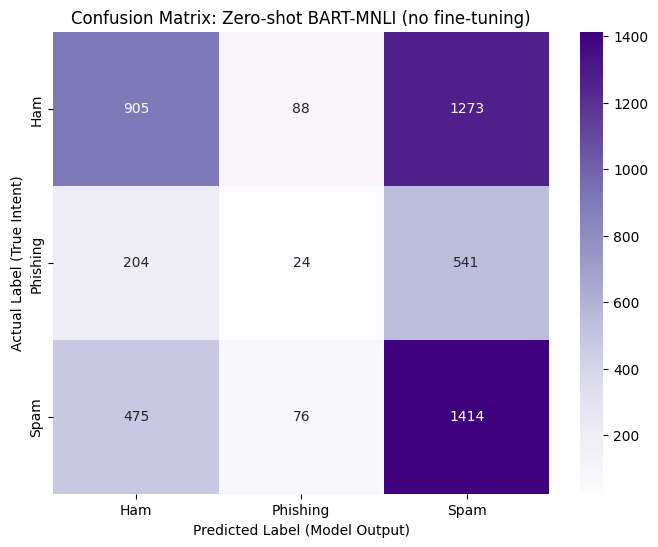


Predictions saved to models/predictions/


In [33]:
# ===========================================================================
# 12.1 Zero-Shot Classification using Hugging Face Pipeline (Quantitative)
# ===========================================================================
# 1. Build a stratified 5000-email subset of the test set
import  time, tqdm
print("Building stratified evaluation subset...")
# Assuming X_test and y_test are available in your environment from previous splits
test_df = pd.DataFrame({
    'text':  X_test.values,
    'label': y_test.values
})

# Stratified sampling preserves class proportions (Ham/Phishing/Spam)
from sklearn.model_selection import train_test_split
zero_shot_subset, _ = train_test_split(
    test_df,
    train_size=5000,
    random_state=42,
    stratify=test_df['label']
)
zero_shot_subset = zero_shot_subset.reset_index(drop=True)

print(f"Subset size: {len(zero_shot_subset)}")
print("Class distribution in subset:")
print(zero_shot_subset['label'].value_counts(normalize=True).sort_index() * 100)


# 2. Load the zero-shot classification pipeline
print("\nLoading facebook/bart-large-mnli (this may download ~1.6GB on first run)...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0    # use GPU (set to -1 to force CPU)
)

# 3. Define candidate labels with descriptive hypotheses
# The exact wording matters: NLI models are sensitive to how labels are phrased
candidate_labels = [
    "a legitimate personal or business email",
    "a phishing attempt designed to steal personal information",
    "an unsolicited spam or promotional message"
]

# Map descriptive labels back to our integer label space
label_mapping = {
    candidate_labels[0]: 0,  # Ham
    candidate_labels[1]: 1,  # Phishing
    candidate_labels[2]: 2,  # Spam
}


# 4. Run inference 
print("\nRunning zero-shot classification on 5,000 emails...")
print("This will take roughly 30-60 minutes on CPU.\n")

predictions_zero_shot = []
start_time = time.time()

for text in tqdm.tqdm(zero_shot_subset['text'].values, desc="Classifying"):
    # Use Hugging Face's native token-level truncation instead of slicing strings manually
    result = zero_shot_classifier(
        str(text), 
        candidate_labels, 
        multi_label=False, 
        truncation=True, 
        max_length=1024
    )
    # The pipeline returns labels sorted by confidence, top one first
    top_label = result['labels'][0]
    predictions_zero_shot.append(label_mapping[top_label])

elapsed_min = (time.time() - start_time) / 60
print(f"\nInference completed in {elapsed_min:.1f} minutes.")


# 5. Evaluate
y_true_zs = zero_shot_subset['label'].values
y_pred_zs = np.array(predictions_zero_shot)

# Define target_names to prevent NameError during evaluation
target_names = ["Ham", "Phishing", "Spam"]

print("\n" + "=" * 50)
print("ZERO-SHOT CLASSIFICATION REPORT (BART-MNLI)")
print("=" * 50)
print(classification_report(y_true_zs, y_pred_zs, target_names=target_names, digits=4))


# 6. Confusion matrix
cm_zs = confusion_matrix(y_true_zs, y_pred_zs)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_zs, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Zero-shot BART-MNLI (no fine-tuning)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()


# 7. Save predictions for later cross-comparison
os.makedirs('models/predictions', exist_ok=True)
np.save('models/predictions/y_pred_zero_shot_bart.npy', y_pred_zs)
np.save('models/predictions/y_true_zero_shot_subset.npy',  y_true_zs)
print("\nPredictions saved to models/predictions/")

#### 12.1. Zero-Shot Results Analysis
[[go back to the topic]](#12-zero-shot-prompting)

The zero-shot classification experiment with `facebook/bart-large-mnli` yields a clear and important conclusion: **zero-shot NLI cannot replace fine-tuning for domain-specific classification tasks**.

##### Quantitative Results

| Model | Macro F1 | Ham Recall | Phishing Recall | Spam Recall |
|---|---|---|---|---|
| BART-MNLI (Zero-Shot) | 35.50% | 39.94% | 3.12% | 71.96% |
| DistilBERT + LoRA (Fine-Tuned) | **98.76%** | **99.18%** | **98.43%** | **98.39%** |

The performance gap is striking: **63.26 percentage points** in macro F1.

##### Key Findings

**1. Catastrophic Phishing Recall (3.12%):**  
BART-MNLI almost entirely fails to identify phishing emails, misclassifying 96.88% of them as either Ham or Spam. This is the most critical failure from a security standpoint. Zero-shot NLI relies on semantic overlap between the input text and the label description. The label *"a phishing attempt designed to steal personal information"* requires domain knowledge that BART's general-purpose pre-training has not reliably encoded at the classification boundary level.

**2. Spam Bias (71.96% recall):**  
The model over-predicts "Spam" as the catch-all malicious category, incorrectly labelling many legitimate Ham emails and true Phishing emails as Spam. This suggests BART-MNLI interprets the "unsolicited spam" label as the dominant adversarial category, lacking the nuance to distinguish structured social engineering (Phishing) from bulk promotional email.

**3. Inference Speed Advantage:**  
Despite its poor accuracy, BART-MNLI completed inference on 5,000 emails in **8.5 minutes**, without any training. Fine-tuning DistilBERT required approximately 5.5 hours. This trade-off is only worthwhile when annotated data is completely unavailable.

##### Conclusion

Zero-shot classification is a powerful prototyping tool but is not suitable for production deployment in cybersecurity contexts, where misclassifying phishing as Ham directly translates to security breaches. Fine-tuning on labelled domain data, even with parameter-efficient methods like LoRA, is strongly preferable whenever training data is available.


### 13. Conclusion
[[go back to the top]](#table-of-contents)


#### 13.1. Summary of Findings
[[go back to the topic]](#13-conclusion)

This assignment demonstrated the superiority of Transformer-based architectures over traditional machine learning pipelines for the three-class email classification task (Ham / Phishing / Spam).

**Key results:**

| Architecture | Macro F1 | Phishing Recall | Phishing Precision |
|---|---|---|---|
| MLP Optuna (TF-IDF) — Assignment 1 | 96.00% | 94.00% | 92.00% |
| MLP Weighted (Word2Vec) — Assignment 1 | 96.00% | 98.00% | 90.00% |
| DistilBERT Baseline (No Weights) | 98.77% | 98.53% | 99.13% |
| **DistilBERT + LoRA + Class Weights** | **98.76%** | **98.43%** | **99.23%** |
| RoBERTa Cost-Sensitive | 98.42% | 99.47% | 97.48% |
| RoBERTa Baseline | 98.68% | 98.96% | 98.45% |
| BART-MNLI (Zero-Shot) | 35.50% | 3.12% | — |

The fine-tuned **DistilBERT + LoRA + Cost-Sensitive Learning** model is the recommended production system. It achieves a superior balance between threat detection (98.43% Phishing Recall) and precision (99.23%), with only **128 undetected phishing emails** across the 55,687-email test set. Crucially, this was accomplished by updating only **1.094%** of the model's parameters through PEFT/LoRA, making the approach computationally tractable on consumer GPU hardware.




#### 13.2. Limitations
[[go back to the topic]](#13-conclusion)

1. **Data skew**: The training set is drawn from public phishing corpora and may not capture state-of-the-art adversarial tactics (e.g., LLM-generated phishing content).
2. **Truncation at 256 tokens**: Long multi-part emails may lose content beyond the opening segment, potentially affecting classification of edge cases.
3. **Class definition overlap**: The boundary between Spam and Phishing is inherently subjective in some cases (e.g., aggressive marketing vs. social engineering), which may introduce label noise.
4. **Out-of-domain fragility**: The SMS generalization experiment (Section 11.2) showed that the model's accuracy drops significantly on a different medium, confirming the need for domain-specific training data.

#### 13.3. Future Work
[[go back to the topic]](#13-conclusion)

- **Domain adaptation pre-training** (Section 11.1 code): Continuing MLM on the email corpus before fine-tuning may further improve performance, especially for adversarial email variants.
- **LLM-generated phishing**: Evaluating robustness against phishing emails generated by large language models (GPT-4, Claude, etc.).
- **Ensemble approaches**: Combining DistilBERT's contextual embeddings with TF-IDF features as a hybrid classifier.
- **Inference optimization**: Applying quantization or ONNX export to reduce DistilBERT's inference latency for real-time email filtering pipelines.

---
### 14. References
[[go back to the top]](#table-of-contents)

1. **Sanh, V., Debut, L., Chaumond, J., & Wolf, T.** (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. *arXiv preprint arXiv:1910.01108*. https://arxiv.org/abs/1910.01108

2. **Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., ... & Stoyanov, V.** (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv preprint arXiv:1907.11692*. https://arxiv.org/abs/1907.11692

3. **Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., ... & Chen, W.** (2021). LoRA: Low-Rank Adaptation of Large Language Models. *arXiv preprint arXiv:2106.09685*. https://arxiv.org/abs/2106.09685

4. **Lewis, M., Liu, Y., Goyal, N., Ghazvininejad, M., Mohamed, A., Levy, O., ... & Zettlemoyer, L.** (2019). BART: Denoising Sequence-to-Sequence Pre-training for Natural Language Generation, Translation, and Comprehension. *arXiv preprint arXiv:1910.13461*. https://arxiv.org/abs/1910.13461

5. **Devlin, J., Chang, M. W., Lee, K., & Toutanova, K.** (2018). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *arXiv preprint arXiv:1810.04805*. https://arxiv.org/abs/1810.04805

6. **Hugging Face.** (2022). The Hugging Face NLP Course — Chapter 7: Main NLP Tasks. https://huggingface.co/course/chapter7/3?fw=pt

7. **Hugging Face.** (2024). PEFT: State-of-the-art Parameter-Efficient Fine-Tuning. https://huggingface.co/docs/peft/main/quicktour

8. **Nazario, J.** (2007). PhishingCorpus. *Monkey.org*. Used as the primary phishing email source for the dataset construction in this project.

9. **Almeida, T. A., Gómez Hidalgo, J. M., & Yamakami, A.** (2011). Contributions to the Study of SMS Spam Filtering: New Collection and Results. In *Proceedings of the 2011 ACM Symposium on Document Engineering* (pp. 259-262). https://doi.org/10.1145/2034691.2034742


##### ⚠️ Session Restore
[[go back to the top]](#table-of-contents)

Run this cell **only** if the kernel restarts before Section 10.

In [3]:
# ===========================================================================
# ⚠️  SESSION RESTORE — Run this cell ONLY if the kernel has been restarted
# This rebuilds variables from disk so you can continue from Section 10 onwards.
# ===========================================================================
print("1. Loading RoBERTa variables and configurations...")
roberta_checkpoint = "roberta-base"
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}
OPTIMAL_MAX_LENGTH = 256

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Initialize RoBERTa-specific tokenizer and collator
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_checkpoint)
roberta_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1_macro': f1, 'precision': precision, 'recall': recall}

print("2. Rebuilding the tokenized datasets specifically for RoBERTa...")
df = pd.read_csv('data/df_preprocessed_final.csv').dropna(subset=['text', 'label'])

X = df['text'].astype(str)
y = df['label'].astype(int)

# Exact same 3-stage split as in Section 2.1 to prevent data leakage
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_pool, X_val, y_train_pool, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=42, stratify=y_train_full
)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_pool, y_train_pool,
    train_size=0.80, random_state=42, stratify=y_train_pool
)

roberta_dataset = DatasetDict({
    'train':      Dataset.from_dict({'text': X_train_sub.values, 'label': y_train_sub.values}),
    'validation': Dataset.from_dict({'text': X_val.values,       'label': y_val.values}),
    'test':       Dataset.from_dict({'text': X_test.values,      'label': y_test.values})
})

def roberta_tokenize(examples):
    return roberta_tokenizer(examples["text"], truncation=True, max_length=OPTIMAL_MAX_LENGTH)

print(f"Tokenizing datasets with RoBERTa tokenizer (max_length={OPTIMAL_MAX_LENGTH})...")
tokenized_roberta = roberta_dataset.map(roberta_tokenize, batched=True)
tokenized_roberta = tokenized_roberta.remove_columns(["text"])
tokenized_roberta.set_format("torch")

print("RoBERTa Session successfully restored. Ready to proceed with Section 10.")

1. Loading RoBERTa variables and configurations...


2. Rebuilding the tokenized datasets specifically for RoBERTa...
Tokenizing datasets with RoBERTa tokenizer (max_length=256)...


Map: 100%|██████████| 55687/55687 [00:08<00:00, 6449.90 examples/s]

RoBERTa Session successfully restored. Ready to proceed with Section 10.
